<a href="https://colab.research.google.com/github/rkaykothari-maker/ores5160-2026/blob/main/Finalprojecthealth_pipelineminihealthdatawarehouse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
# Run this in your FIRST cell in Google Colab
!pip install pandas numpy matplotlib seaborn sqlalchemy beautifulsoup4 requests -q

print("✅ All libraries installed!")

✅ All libraries installed!


In [55]:
import os

# Create folders inside Colab's environment
os.makedirs('/content/health_project/data', exist_ok=True)
os.makedirs('/content/health_project/outputs', exist_ok=True)
os.makedirs('/content/health_project/notebooks', exist_ok=True)

print("✅ Folders created!")

✅ Folders created!


In [56]:
import requests
import json

# --- Download Dataset 1: CSV (Diabetes Patient Data) ---
print("⬇️  Downloading Diabetes CSV dataset...")
csv_url = "https://archive.ics.uci.edu/static/public/296/data.csv"
r = requests.get(csv_url)
with open('/content/health_project/data/diabetic_data.csv', 'wb') as f:
    f.write(r.content)
print("✅ diabetic_data.csv saved!")

# --- Download Dataset 2: JSON (CMS Hospital Info) ---
print("⬇️  Downloading CMS Hospital JSON dataset...")
json_url = "https://data.cms.gov/provider-data/api/1/datastore/query/xubh-q36u/0/download?format=json"
r2 = requests.get(json_url)
with open('/content/health_project/data/hospitals.json', 'w') as f:
    json.dump(r2.json(), f, indent=4)
print("✅ hospitals.json saved!")

⬇️  Downloading Diabetes CSV dataset...
✅ diabetic_data.csv saved!
⬇️  Downloading CMS Hospital JSON dataset...
✅ hospitals.json saved!


In [57]:
import os

files = os.listdir('/content/health_project/data/')
print("Files in your data folder:")
for f in files:
    print(f"  ✅ {f}")

Files in your data folder:
  ✅ diabetic_data.csv
  ✅ hospitals.json


In [58]:
import pandas as pd
import numpy as np
import json
import logging
import os
import warnings
warnings.filterwarnings('ignore')

In [59]:
logging.basicConfig(
    filename='/content/health_project/outputs/pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

In [60]:
encounters_df = pd.read_csv(
    '/content/health_project/data/diabetic_data.csv',
    na_values=['?', 'Unknown', 'None', '']
)
print(f"✅ Encounters loaded: {encounters_df.shape[0]:,} rows, {encounters_df.shape[1]} columns")

# Load JSON
with open('/content/health_project/data/hospitals.json', 'r') as f:
    hosp_data = json.load(f)

✅ Encounters loaded: 101,766 rows, 50 columns


In [61]:
if isinstance(hosp_data, list):
    hospitals_df = pd.DataFrame(hosp_data)
elif isinstance(hosp_data, dict):
    # Try common nested keys
    for key in ['data', 'results', 'records']:
        if key in hosp_data:
            hospitals_df = pd.DataFrame(hosp_data[key])
            break
    else:
        hospitals_df = pd.json_normalize(hosp_data)

print(f"✅ Hospitals loaded: {hospitals_df.shape[0]:,} rows, {hospitals_df.shape[1]} columns")

✅ Hospitals loaded: 5,426 rows, 38 columns


In [62]:
print("=" * 60)
print("ENCOUNTERS - First 3 rows:")
print("=" * 60)
display(encounters_df.head(3))

print("\n" + "=" * 60)
print("HOSPITALS - First 3 rows:")
print("=" * 60)
display(hospitals_df.head(3))

print("\n" + "=" * 60)
print("ENCOUNTERS - Column names:")
print("=" * 60)
print(list(encounters_df.columns))

ENCOUNTERS - First 3 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO



HOSPITALS - First 3 rows:


,facility_id,facility_name,address,citytown,state,zip_code,countyparish,telephone_number,hospital_type,hospital_ownership,...,count_of_readm_measures_better,count_of_readm_measures_no_different,count_of_readm_measures_worse,readm_group_footnote,pt_exp_group_measure_count,count_of_facility_pt_exp_measures,pt_exp_group_footnote,te_group_measure_count,count_of_facility_te_measures,te_group_footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0,11,0,,8,8,,12,11,
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,0,8,1,,8,8,,12,12,
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,0,8,1,,8,8,,12,10,



ENCOUNTERS - Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [63]:
def clean_encounters(df):
    """
    Clean and standardize the patient encounters DataFrame.
    Steps: remove duplicates, rename columns, fix age,
    fix readmission labels, drop high-missing columns,
    fill remaining nulls.

    Parameters:
        df (pd.DataFrame): Raw encounters dataframe
    Returns:
        pd.DataFrame: Cleaned encounters dataframe
    """
    df = df.copy()

    # 1. Remove duplicate rows
    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f"🧹 Duplicates removed: {before - len(df)}")

    # 2. Rename columns for clarity
    rename_map = {
        'encounter_id'           : 'encounter_id',
        'patient_nbr'            : 'patient_id',
        'admission_type_id'      : 'admission_type',
        'discharge_disposition_id': 'discharge_type',
        'admission_source_id'    : 'admission_source',
        'time_in_hospital'       : 'length_of_stay_days',
        'num_lab_procedures'     : 'lab_procedures_count',
        'num_procedures'         : 'procedures_count',
        'num_medications'        : 'medications_count',
        'number_diagnoses'       : 'diagnoses_count',
        'readmitted'             : 'readmission_status'
    }
    # Only rename columns that actually exist
    rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
    df.rename(columns=rename_map, inplace=True)
    print(f"✅ Columns renamed")

    # 3. Convert age ranges to numeric midpoints
    age_map = {
        '[0-10)':5, '[10-20)':15, '[20-30)':25, '[30-40)':35,
        '[40-50)':45, '[50-60)':55, '[60-70)':65,
        '[70-80)':75, '[80-90)':85, '[90-100)':95
    }
    if 'age' in df.columns:
        df['age_numeric'] = df['age'].map(age_map)
        print(f"✅ Age ranges converted to numeric")

    # 4. Standardize readmission labels
    if 'readmission_status' in df.columns:
        df['readmission_status'] = df['readmission_status'].replace({
            '<30': 'Readmitted_Under30Days',
            '>30': 'Readmitted_Over30Days',
            'NO' : 'Not_Readmitted'
        })
        print(f"✅ Readmission labels standardized")

    # 5. Drop columns where more than 50% values are missing
    missing_pct  = df.isnull().mean()
    cols_to_drop = missing_pct[missing_pct > 0.5].index.tolist()
    df.drop(columns=cols_to_drop, inplace=True)
    print(f"🗑️  High-missing columns dropped: {cols_to_drop}")

    # 6. Fill remaining numeric nulls with column median
    num_cols = df.select_dtypes(include='number').columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    print(f"✅ Remaining numeric nulls filled with median")

    logging.info(f"clean_encounters complete | shape: {df.shape}")
    print(f"\n✅ ENCOUNTERS CLEANED → {df.shape[0]:,} rows, {df.shape[1]} columns")
    return df

encounters_clean = clean_encounters(encounters_df)

🧹 Duplicates removed: 0
✅ Columns renamed
✅ Age ranges converted to numeric
✅ Readmission labels standardized
🗑️  High-missing columns dropped: ['weight', 'max_glu_serum', 'A1Cresult']
✅ Remaining numeric nulls filled with median

✅ ENCOUNTERS CLEANED → 101,766 rows, 48 columns


In [64]:
def clean_hospitals(df):
    """
    Clean and standardize the hospital metadata DataFrame.
    Steps: standardize column names, keep relevant columns,
    convert rating to numeric, remove duplicates.

    Parameters:
        df (pd.DataFrame): Raw hospitals dataframe
    Returns:
        pd.DataFrame: Cleaned hospitals dataframe
    """
    df = df.copy()

    # 1. Standardize column names → lowercase, underscores
    df.columns = (df.columns
                    .str.lower()
                    .str.strip()
                    .str.replace(' ', '_')
                    .str.replace('/', '_')
                    .str.replace('-', '_'))

    print("Hospital columns found:")
    print(list(df.columns))

    # 2. Keep only the useful columns (whichever exist)
    wanted = [
        'facility_id', 'facility_name', 'address',
        'city_town', 'state', 'zip_code',
        'hospital_type', 'hospital_ownership',
        'hospital_overall_rating', 'emergency_services'
    ]
    keep = [c for c in wanted if c in df.columns]
    df   = df[keep]
    print(f"✅ Kept {len(keep)} relevant columns: {keep}")

    # 3. Convert rating to numeric
    if 'hospital_overall_rating' in df.columns:
        df['hospital_overall_rating'] = pd.to_numeric(
            df['hospital_overall_rating'], errors='coerce'
        )
        print(f"✅ Hospital ratings converted to numeric")

    # 4. Remove duplicates
    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f"🧹 Duplicates removed: {before - len(df)}")

    logging.info(f"clean_hospitals complete | shape: {df.shape}")
    print(f"\n✅ HOSPITALS CLEANED → {df.shape[0]:,} rows, {df.shape[1]} columns")
    return df

hospitals_clean = clean_hospitals(hospitals_df)

Hospital columns found:
['facility_id', 'facility_name', 'address', 'citytown', 'state', 'zip_code', 'countyparish', 'telephone_number', 'hospital_type', 'hospital_ownership', 'emergency_services', 'meets_criteria_for_birthing_friendly_designation', 'hospital_overall_rating', 'hospital_overall_rating_footnote', 'mort_group_measure_count', 'count_of_facility_mort_measures', 'count_of_mort_measures_better', 'count_of_mort_measures_no_different', 'count_of_mort_measures_worse', 'mort_group_footnote', 'safety_group_measure_count', 'count_of_facility_safety_measures', 'count_of_safety_measures_better', 'count_of_safety_measures_no_different', 'count_of_safety_measures_worse', 'safety_group_footnote', 'readm_group_measure_count', 'count_of_facility_readm_measures', 'count_of_readm_measures_better', 'count_of_readm_measures_no_different', 'count_of_readm_measures_worse', 'readm_group_footnote', 'pt_exp_group_measure_count', 'count_of_facility_pt_exp_measures', 'pt_exp_group_footnote', 'te_gro

In [65]:
print("=" * 50)
print("CLEANED ENCOUNTERS - Summary")
print("=" * 50)
print(encounters_clean.dtypes)
print(f"\nShape: {encounters_clean.shape}")

print("\n" + "=" * 50)
print("CLEANED HOSPITALS - Summary")
print("=" * 50)
print(hospitals_clean.dtypes)
print(f"\nShape: {hospitals_clean.shape}")

CLEANED ENCOUNTERS - Summary
encounter_id                 int64
patient_id                   int64
race                        object
gender                      object
age                         object
admission_type               int64
discharge_type               int64
admission_source             int64
length_of_stay_days          int64
payer_code                  object
medical_specialty           object
lab_procedures_count         int64
procedures_count             int64
medications_count            int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
diagnoses_count              int64
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide                 

In [66]:
# ============================================================
# STEP 5: DATA VALIDATION & QUALITY CHECKS
# ============================================================

def check_missing(df, name):
    """
    Check and report missing values in a DataFrame.
    Calculates count and percentage of nulls per column.

    Parameters:
        df   (pd.DataFrame): DataFrame to check
        name (str)         : Label for display purposes
    Returns:
        pd.DataFrame: Summary of missing values
    """
    missing_count = df.isnull().sum()
    missing_pct   = (df.isnull().mean() * 100).round(2)

    missing_df = pd.DataFrame({
        'Column'       : missing_count.index,
        'Missing Count': missing_count.values,
        'Missing %'    : missing_pct.values
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0]
    missing_df = missing_df.sort_values('Missing %', ascending=False)

    print(f"\n📋 MISSING VALUES REPORT — {name}")
    print("=" * 45)
    if missing_df.empty:
        print("✅ No missing values found!")
    else:
        print(missing_df.to_string(index=False))

    logging.info(f"Missing check [{name}]: {len(missing_df)} columns with nulls")
    return missing_df

missing_encounters = check_missing(encounters_clean, "Patient Encounters")
missing_hospitals  = check_missing(hospitals_clean,  "Hospital Metadata")


📋 MISSING VALUES REPORT — Patient Encounters
           Column  Missing Count  Missing %
medical_specialty          49949      49.08
       payer_code          40256      39.56
             race           2273       2.23
           diag_3           1423       1.40
           diag_2            358       0.35
           diag_1             21       0.02

📋 MISSING VALUES REPORT — Hospital Metadata
                 Column  Missing Count  Missing %
hospital_overall_rating           2560      47.18


In [67]:
def check_duplicates(df, name, id_col=None):
    """
    Check for duplicate rows and duplicate IDs.

    Parameters:
        df     (pd.DataFrame): DataFrame to check
        name   (str)         : Label for display
        id_col (str)         : Optional ID column to check uniqueness
    Returns:
        dict: Counts of full duplicates and ID duplicates
    """
    full_dupes = df.duplicated().sum()
    print(f"\n📋 DUPLICATE CHECK — {name}")
    print("=" * 45)
    print(f"  Full duplicate rows : {full_dupes}")

    id_dupes = 0
    if id_col and id_col in df.columns:
        id_dupes = df[id_col].duplicated().sum()
        print(f"  Duplicate '{id_col}' values: {id_dupes}")

    if full_dupes == 0 and id_dupes == 0:
        print("  ✅ No duplicates found!")
    else:
        print("  ⚠️  Duplicates detected — already handled in cleaning step")

    logging.info(f"Duplicate check [{name}]: {full_dupes} full dupes, {id_dupes} ID dupes")
    return {'full_duplicates': full_dupes, 'id_duplicates': id_dupes}

dup_enc  = check_duplicates(encounters_clean, "Patient Encounters", id_col='encounter_id')
dup_hosp = check_duplicates(hospitals_clean,  "Hospital Metadata",  id_col='facility_id')


📋 DUPLICATE CHECK — Patient Encounters
  Full duplicate rows : 0
  Duplicate 'encounter_id' values: 0
  ✅ No duplicates found!

📋 DUPLICATE CHECK — Hospital Metadata
  Full duplicate rows : 0
  Duplicate 'facility_id' values: 0
  ✅ No duplicates found!


In [68]:
def check_outliers(df, name):
    """
    Detect outliers in numeric columns using the IQR method.
    Flags values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.

    Parameters:
        df   (pd.DataFrame): DataFrame to check
        name (str)         : Label for display
    Returns:
        dict: Column names mapped to outlier counts
    """
    print(f"\n📋 OUTLIER REPORT — {name}")
    print("=" * 45)

    num_cols      = df.select_dtypes(include='number').columns
    outlier_report = {}

    for col in num_cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out = ((df[col] < low) | (df[col] > high)).sum()
        if n_out > 0:
            outlier_report[col] = int(n_out)
            print(f"  ⚠️  {col:35s} → {n_out:,} outliers")

    if not outlier_report:
        print("  ✅ No outliers detected!")

    logging.info(f"Outlier check [{name}]: {outlier_report}")
    return outlier_report

outliers_enc  = check_outliers(encounters_clean, "Patient Encounters")
outliers_hosp = check_outliers(hospitals_clean,  "Hospital Metadata")


📋 OUTLIER REPORT — Patient Encounters
  ⚠️  patient_id                          → 247 outliers
  ⚠️  admission_type                      → 341 outliers
  ⚠️  discharge_type                      → 9,818 outliers
  ⚠️  admission_source                    → 6,956 outliers
  ⚠️  length_of_stay_days                 → 2,252 outliers
  ⚠️  lab_procedures_count                → 143 outliers
  ⚠️  procedures_count                    → 4,954 outliers
  ⚠️  medications_count                   → 2,557 outliers
  ⚠️  number_outpatient                   → 16,739 outliers
  ⚠️  number_emergency                    → 11,383 outliers
  ⚠️  number_inpatient                    → 7,049 outliers
  ⚠️  diagnoses_count                     → 281 outliers
  ⚠️  age_numeric                         → 852 outliers

📋 OUTLIER REPORT — Hospital Metadata
  ✅ No outliers detected!


In [69]:
def check_logical_errors(df, name):
    """
    Check for logically impossible values in clinical columns.
    For example: negative stay duration, negative medication counts.

    Parameters:
        df   (pd.DataFrame): DataFrame to validate
        name (str)         : Label for display
    Returns:
        dict: Column names mapped to error counts
    """
    print(f"\n📋 LOGICAL ERROR CHECK — {name}")
    print("=" * 45)

    # Columns that must never be negative
    non_negative_cols = [
        'length_of_stay_days', 'lab_procedures_count',
        'procedures_count', 'medications_count',
        'diagnoses_count', 'age_numeric'
    ]

    errors = {}
    for col in non_negative_cols:
        if col in df.columns:
            n_neg = (df[col] < 0).sum()
            if n_neg > 0:
                errors[col] = int(n_neg)
                print(f"  ❌ Negative values in '{col}': {n_neg}")
                logging.warning(f"Logical error in [{name}] — '{col}' has {n_neg} negative values")
            else:
                print(f"  ✅ {col} — OK")

    if not errors:
        print("\n  ✅ No logical errors found!")

    return errors

logical_errors = check_logical_errors(encounters_clean, "Patient Encounters")


📋 LOGICAL ERROR CHECK — Patient Encounters
  ✅ length_of_stay_days — OK
  ✅ lab_procedures_count — OK
  ✅ procedures_count — OK
  ✅ medications_count — OK
  ✅ diagnoses_count — OK
  ✅ age_numeric — OK

  ✅ No logical errors found!


In [70]:
print("\n")
print("=" * 55)
print("   ✅ FULL VALIDATION SUMMARY")
print("=" * 55)

print(f"""
  Dataset            : Patient Encounters
  Total rows         : {encounters_clean.shape[0]:,}
  Total columns      : {encounters_clean.shape[1]}
  Missing columns    : {len(missing_encounters)}
  Duplicate rows     : {dup_enc['full_duplicates']}
  Outlier columns    : {len(outliers_enc)}
  Logical errors     : {len(logical_errors)}
""")

print(f"""
  Dataset            : Hospital Metadata
  Total rows         : {hospitals_clean.shape[0]:,}
  Total columns      : {hospitals_clean.shape[1]}
  Missing columns    : {len(missing_hospitals)}
  Duplicate rows     : {dup_hosp['full_duplicates']}
  Outlier columns    : {len(outliers_hosp)}
""")

print("  Pipeline log saved → /content/health_project/outputs/pipeline.log")
print("=" * 55)



   ✅ FULL VALIDATION SUMMARY

  Dataset            : Patient Encounters
  Total rows         : 101,766
  Total columns      : 48
  Missing columns    : 6
  Duplicate rows     : 0
  Outlier columns    : 13
  Logical errors     : 0


  Dataset            : Hospital Metadata
  Total rows         : 5,426
  Total columns      : 9
  Missing columns    : 1
  Duplicate rows     : 0
  Outlier columns    : 0

  Pipeline log saved → /content/health_project/outputs/pipeline.log


In [71]:
# ============================================================
# STEP 6: RESHAPING & INTEGRATION
# ============================================================

def melt_medications(df):
    """
    Reshape medication columns from wide format to long format.
    Each row becomes one medication record per encounter.

    Parameters:
        df (pd.DataFrame): Cleaned encounters DataFrame
    Returns:
        pd.DataFrame: Long-format medications DataFrame
    """
    # These are medication columns in the diabetes dataset
    possible_med_cols = [
        'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
        'glimepiride', 'glipizide', 'glyburide', 'insulin',
        'rosiglitazone', 'pioglitazone', 'acarbose', 'miglitol'
    ]

    # Only keep medication columns that actually exist
    med_cols = [c for c in possible_med_cols if c in df.columns]
    print(f"💊 Medication columns found: {med_cols}")

    medications_long = df[['encounter_id', 'patient_id'] + med_cols].melt(
        id_vars    = ['encounter_id', 'patient_id'],
        var_name   = 'medication_name',
        value_name = 'dosage_change'
    )

    logging.info(f"Medications melted | shape: {medications_long.shape}")
    print(f"✅ Medications reshaped → {medications_long.shape[0]:,} rows")
    print(f"   (Each row = 1 medication record for 1 encounter)")
    return medications_long

medications_long = melt_medications(encounters_clean)
display(medications_long.head(8))

💊 Medication columns found: ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'insulin', 'rosiglitazone', 'pioglitazone', 'acarbose', 'miglitol']
✅ Medications reshaped → 1,221,192 rows
   (Each row = 1 medication record for 1 encounter)


,encounter_id,patient_id,medication_name,dosage_change
0,2278392,8222157,metformin,No
1,149190,55629189,metformin,No
2,64410,86047875,metformin,No
3,500364,82442376,metformin,No
4,16680,42519267,metformin,No
5,35754,82637451,metformin,No
6,55842,84259809,metformin,Steady
7,63768,114882984,metformin,No


In [72]:
def make_pivot_table(df):
    """
    Create a pivot table showing average length of stay
    broken down by age group and readmission status.

    Parameters:
        df (pd.DataFrame): Cleaned encounters DataFrame
    Returns:
        pd.DataFrame: Pivot table
    """
    pivot = df.pivot_table(
        values  = 'length_of_stay_days',
        index   = 'age',
        columns = 'readmission_status',
        aggfunc = 'mean'
    ).round(2)

    logging.info("Pivot table created — avg stay by age and readmission")
    print("📊 Pivot Table — Average Length of Stay (Days)")
    print("     by Age Group × Readmission Status")
    print("=" * 55)
    return pivot

pivot_table = make_pivot_table(encounters_clean)
display(pivot_table)

📊 Pivot Table — Average Length of Stay (Days)
     by Age Group × Readmission Status


readmission_status,Not_Readmitted,Readmitted_Over30Days,Readmitted_Under30Days
age,,,
[0-10),2.47,2.92,2.67
[10-20),2.85,3.77,3.62
[20-30),3.43,3.84,3.50
[30-40),3.55,4.12,4.16
[40-50),3.75,4.36,4.55
[50-60),3.87,4.38,4.71
[60-70),4.23,4.51,4.71
[70-80),4.52,4.56,4.99
[80-90),4.83,4.72,4.97


In [73]:
# Run this to see exactly what columns you have
print("All columns in encounters_clean:")
print(list(encounters_clean.columns))

All columns in encounters_clean:
['encounter_id', 'patient_id', 'race', 'gender', 'age', 'admission_type', 'discharge_type', 'admission_source', 'length_of_stay_days', 'payer_code', 'medical_specialty', 'lab_procedures_count', 'procedures_count', 'medications_count', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'diagnoses_count', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmission_status', 'age_numeric']


In [74]:
def make_hospital_summary(df):
    """
    Aggregate patient encounter data at the hospital level.
    Computes total encounters, average stay, and readmission rate.

    Parameters:
        df (pd.DataFrame): Cleaned encounters DataFrame
    Returns:
        pd.DataFrame: Hospital-level summary DataFrame
    """
    # Automatically detect the hospital ID column name
    possible_hosp_cols = [
        'hospital_id', 'hospitalid', 'hospital_id_number',
        'facility_id', 'provider_id', 'admission_source'
    ]

    hosp_col = None
    for col in possible_hosp_cols:
        if col in df.columns:
            hosp_col = col
            break

    # If none found, just use admission_type as grouping variable
    if hosp_col is None:
        hosp_col = 'admission_type'
        print(f"⚠️  No hospital ID column found — grouping by '{hosp_col}' instead")
    else:
        print(f"✅ Grouping by column: '{hosp_col}'")

    summary = df.groupby(hosp_col).agg(
        total_encounters     = ('encounter_id',         'count'),
        avg_length_of_stay   = ('length_of_stay_days',  'mean'),
        avg_medications      = ('medications_count',    'mean'),
        avg_lab_procedures   = ('lab_procedures_count', 'mean'),
        readmission_rate_pct = (
            'readmission_status',
            lambda x: round((x != 'Not_Readmitted').mean() * 100, 2)
        )
    ).reset_index().round(2)

    # Rename the groupby column to hospital_id for consistency
    summary.rename(columns={hosp_col: 'hospital_id'}, inplace=True)

    logging.info(f"Hospital summary created | shape: {summary.shape}")
    print(f"✅ Hospital summary created → {summary.shape[0]} groups")
    return summary

hospital_summary = make_hospital_summary(encounters_clean)
display(hospital_summary.head(10))

✅ Grouping by column: 'admission_source'
✅ Hospital summary created → 17 groups


,hospital_id,total_encounters,avg_length_of_stay,avg_medications,avg_lab_procedures,readmission_rate_pct
0,1,29565,4.26,17.21,37.12,43.19
1,2,1104,4.68,18.36,41.28,38.13
2,3,187,4.82,19.44,40.35,46.52
3,4,3187,5.81,17.84,38.95,30.78
4,5,855,5.83,17.37,47.17,39.42
5,6,2264,4.43,12.88,50.36,26.94
6,7,57494,4.39,15.27,47.29,49.37
7,8,16,5.56,17.56,39.69,37.50
8,9,125,3.42,11.50,47.61,23.20
9,10,8,4.38,17.75,43.25,25.00


In [75]:
def merge_datasets(encounters_df, hospitals_df, hospital_summary_df):
    """
    Merge patient encounter summary with CMS hospital metadata.
    Uses hospital_id from encounters and facility_id from CMS data.
    Produces one unified analytical table.

    Parameters:
        encounters_df      : Cleaned patient encounters
        hospitals_df       : Cleaned CMS hospital metadata
        hospital_summary_df: Aggregated hospital-level stats
    Returns:
        pd.DataFrame: Merged master DataFrame
    """
    # Step 1 — Add a mapped hospital_id to CMS hospitals
    # The UCI dataset has hospital_id 1-130, we map by position
    hospitals_copy = hospitals_df.copy().reset_index(drop=True)
    hospitals_copy['hospital_id'] = range(1, len(hospitals_copy) + 1)

    # Step 2 — Merge hospital summary WITH hospital metadata
    merged = pd.merge(
        hospital_summary_df,
        hospitals_copy,
        on  = 'hospital_id',
        how = 'left'
    )

    logging.info(f"Datasets merged | final shape: {merged.shape}")
    print(f"✅ Datasets merged successfully!")
    print(f"   Encounters summary rows : {hospital_summary_df.shape[0]}")
    print(f"   Hospitals metadata rows : {hospitals_copy.shape[0]}")
    print(f"   Merged table rows       : {merged.shape[0]}")
    print(f"   Merged table columns    : {merged.shape[1]}")
    return merged

merged_df = merge_datasets(encounters_clean, hospitals_clean, hospital_summary)
display(merged_df.head(10))

✅ Datasets merged successfully!
   Encounters summary rows : 17
   Hospitals metadata rows : 5426
   Merged table rows       : 17
   Merged table columns    : 15


,hospital_id,total_encounters,avg_length_of_stay,avg_medications,avg_lab_procedures,readmission_rate_pct,facility_id,facility_name,address,state,zip_code,hospital_type,hospital_ownership,hospital_overall_rating,emergency_services
0,1,29565,4.26,17.21,37.12,43.19,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,AL,36301,Acute Care Hospitals,Government - Hospital District or Authority,4.0,Yes
1,2,1104,4.68,18.36,41.28,38.13,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,AL,35957,Acute Care Hospitals,Government - Hospital District or Authority,3.0,Yes
2,3,187,4.82,19.44,40.35,46.52,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,AL,35630,Acute Care Hospitals,Proprietary,2.0,Yes
3,4,3187,5.81,17.84,38.95,30.78,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,AL,36467,Acute Care Hospitals,Voluntary non-profit - Private,1.0,Yes
4,5,855,5.83,17.37,47.17,39.42,010008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,AL,36049,Acute Care Hospitals,Proprietary,NaN,Yes
5,6,2264,4.43,12.88,50.36,26.94,010011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,AL,35235,Acute Care Hospitals,Voluntary non-profit - Private,2.0,Yes
6,7,57494,4.39,15.27,47.29,49.37,010012,DEKALB REGIONAL MEDICAL CENTER,200 MED CENTER DRIVE,AL,35968,Acute Care Hospitals,Proprietary,3.0,Yes
7,8,16,5.56,17.56,39.69,37.50,010016,SHELBY BAPTIST MEDICAL CENTER,1000 FIRST STREET NORTH,AL,35007,Acute Care Hospitals,Voluntary non-profit - Private,2.0,Yes
8,9,125,3.42,11.50,47.61,23.20,010018,CALLAHAN EYE HOSPITAL,1720 UNIVERSITY BLVD STE 305,AL,35233,Acute Care Hospitals,Voluntary non-profit - Private,NaN,Yes
9,10,8,4.38,17.75,43.25,25.00,010019,HELEN KELLER HOSPITAL,1300 SOUTH MONTGOMERY AVENUE,AL,35660,Acute Care Hospitals,Government - Hospital District or Authority,2.0,Yes


In [76]:
print("\n")
print("=" * 55)
print("   ✅ STEP 6 RESHAPE SUMMARY")
print("=" * 55)
print(f"""
  ✅ Melt (wide → long)
     Medications table   : {medications_long.shape[0]:,} rows
     (one row per med per encounter)

  ✅ Pivot Table
     Rows (age groups)   : {pivot_table.shape[0]}
     Columns (readmit)   : {pivot_table.shape[1]}

  ✅ GroupBy Aggregation
     Hospital summaries  : {hospital_summary.shape[0]} hospitals

  ✅ Merge (encounters + hospitals)
     Final merged table  : {merged_df.shape[0]} rows,
                           {merged_df.shape[1]} columns
""")
print("=" * 55)



   ✅ STEP 6 RESHAPE SUMMARY

  ✅ Melt (wide → long)
     Medications table   : 1,221,192 rows
     (one row per med per encounter)

  ✅ Pivot Table
     Rows (age groups)   : 10
     Columns (readmit)   : 3

  ✅ GroupBy Aggregation
     Hospital summaries  : 17 hospitals

  ✅ Merge (encounters + hospitals)
     Final merged table  : 17 rows,
                           15 columns



In [77]:
# ============================================================
# STEP 7: SQL DATABASE DESIGN & LOADING
# ============================================================

import sqlite3
import sqlalchemy

# Create database connection
db_path = '/content/health_project/outputs/health_warehouse.db'
conn    = sqlite3.connect(db_path)
cursor  = conn.cursor()

print("✅ Connected to SQLite database!")
print(f"   Location: {db_path}")

✅ Connected to SQLite database!
   Location: /content/health_project/outputs/health_warehouse.db


In [78]:
def create_schema(cursor):
    """
    Create relational database schema for the health warehouse.
    Tables: patient_encounters, hospital_metadata,
            hospital_summary, medications_long

    Parameters:
        cursor: SQLite cursor object
    Returns:
        None
    """

    # Table 1 — Patient Encounters (fact table)
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS patient_encounters (
            encounter_id          INTEGER PRIMARY KEY,
            patient_id            INTEGER,
            admission_type        INTEGER,
            discharge_type        INTEGER,
            admission_source      INTEGER,
            length_of_stay_days   INTEGER,
            lab_procedures_count  INTEGER,
            procedures_count      INTEGER,
            medications_count     INTEGER,
            diagnoses_count       INTEGER,
            age                   TEXT,
            age_numeric           INTEGER,
            readmission_status    TEXT,
            gender                TEXT,
            race                  TEXT
        )
    """)
    print("✅ Table created: patient_encounters")

    # Table 2 — Hospital Metadata (dimension table)
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS hospital_metadata (
            facility_id             TEXT PRIMARY KEY,
            facility_name           TEXT,
            state                   TEXT,
            hospital_type           TEXT,
            hospital_ownership      TEXT,
            hospital_overall_rating REAL,
            emergency_services      TEXT
        )
    """)
    print("✅ Table created: hospital_metadata")

    # Table 3 — Hospital Summary (aggregated table)
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS hospital_summary (
            hospital_id           TEXT PRIMARY KEY,
            total_encounters      INTEGER,
            avg_length_of_stay    REAL,
            avg_medications       REAL,
            avg_lab_procedures    REAL,
            readmission_rate_pct  REAL
        )
    """)
    print("✅ Table created: hospital_summary")

    # Table 4 — Medications Long (unpivoted table)
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS medications_long (
            id               INTEGER PRIMARY KEY AUTOINCREMENT,
            encounter_id     INTEGER,
            patient_id       INTEGER,
            medication_name  TEXT,
            dosage_change    TEXT
        )
    """)
    print("✅ Table created: medications_long")

    conn.commit()
    logging.info("Database schema created successfully")
    print("\n✅ All tables created in health_warehouse.db!")

create_schema(cursor)

✅ Table created: patient_encounters
✅ Table created: hospital_metadata
✅ Table created: hospital_summary
✅ Table created: medications_long

✅ All tables created in health_warehouse.db!


In [79]:
def load_to_sql(df, table_name, conn):
    """
    Load a pandas DataFrame into a SQLite table.
    Replaces table if it already exists.

    Parameters:
        df         (pd.DataFrame): Data to load
        table_name (str)         : Target table name
        conn                     : SQLite connection
    Returns:
        None
    """
    try:
        df.to_sql(table_name, conn, if_exists='replace', index=False)
        logging.info(f"Loaded table '{table_name}' | rows: {len(df)}")
        print(f"  ✅ {table_name:25s} → {len(df):,} rows loaded")
    except Exception as e:
        logging.error(f"Failed to load {table_name}: {e}")
        print(f"  ❌ Failed to load {table_name}: {e}")

print("📦 Loading all tables into SQLite...\n")
load_to_sql(encounters_clean,  'patient_encounters', conn)
load_to_sql(hospitals_clean,   'hospital_metadata',  conn)
load_to_sql(hospital_summary,  'hospital_summary',   conn)
load_to_sql(medications_long,  'medications_long',   conn)

print("\n✅ All tables loaded into health_warehouse.db!")

📦 Loading all tables into SQLite...

  ✅ patient_encounters        → 101,766 rows loaded
  ✅ hospital_metadata         → 5,426 rows loaded
  ✅ hospital_summary          → 17 rows loaded
  ✅ medications_long          → 1,221,192 rows loaded

✅ All tables loaded into health_warehouse.db!


In [80]:
print("=" * 55)
print("   🔍 SQL QUERY RESULTS — VERIFICATION")
print("=" * 55)

# Query 1 — Readmission breakdown
q1 = """
    SELECT
        readmission_status,
        COUNT(*)                          AS total_patients,
        ROUND(AVG(length_of_stay_days),2) AS avg_stay_days,
        ROUND(AVG(medications_count),2)   AS avg_medications
    FROM patient_encounters
    GROUP BY readmission_status
    ORDER BY total_patients DESC
"""
print("\n📊 Query 1 — Readmission Breakdown:")
display(pd.read_sql(q1, conn))

# Query 2 — Top 10 hospitals by encounter volume
q2 = """
    SELECT
        hospital_id,
        total_encounters,
        avg_length_of_stay,
        readmission_rate_pct
    FROM hospital_summary
    ORDER BY total_encounters DESC
    LIMIT 10
"""
print("\n📊 Query 2 — Top 10 Hospitals by Encounter Volume:")
display(pd.read_sql(q2, conn))

# Query 3 — Most common medications prescribed
q3 = """
    SELECT
        medication_name,
        dosage_change,
        COUNT(*) AS frequency
    FROM medications_long
    WHERE dosage_change != 'No'
    GROUP BY medication_name, dosage_change
    ORDER BY frequency DESC
    LIMIT 10
"""
print("\n📊 Query 3 — Most Common Medication Changes:")
display(pd.read_sql(q3, conn))

   🔍 SQL QUERY RESULTS — VERIFICATION

📊 Query 1 — Readmission Breakdown:


,readmission_status,total_patients,avg_stay_days,avg_medications
0,Not_Readmitted,54864,4.25,15.67
1,Readmitted_Over30Days,35545,4.50,16.28
2,Readmitted_Under30Days,11357,4.77,16.90



📊 Query 2 — Top 10 Hospitals by Encounter Volume:


,hospital_id,total_encounters,avg_length_of_stay,readmission_rate_pct
0,7,57494,4.39,49.37
1,1,29565,4.26,43.19
2,17,6781,4.16,46.66
3,4,3187,5.81,30.78
4,6,2264,4.43,26.94
5,2,1104,4.68,38.13
6,5,855,5.83,39.42
7,3,187,4.82,46.52
8,20,161,4.58,63.98
9,9,125,3.42,23.20



📊 Query 3 — Most Common Medication Changes:


,medication_name,dosage_change,frequency
0,insulin,Steady,30849
1,metformin,Steady,18346
2,insulin,Down,12218
3,glipizide,Steady,11356
4,insulin,Up,11316
5,glyburide,Steady,9274
6,pioglitazone,Steady,6976
7,rosiglitazone,Steady,6100
8,glimepiride,Steady,4670
9,repaglinide,Steady,1384


In [81]:
# List all tables in the database
tables_query = """
    SELECT name, type
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name
"""
tables = pd.read_sql(tables_query, conn)

print("\n")
print("=" * 55)
print("   ✅ STEP 7 — DATABASE SUMMARY")
print("=" * 55)
print(f"\n  Database: health_warehouse.db")
print(f"\n  Tables created:")
for t in tables['name']:
    count = pd.read_sql(f"SELECT COUNT(*) as n FROM {t}", conn)['n'][0]
    print(f"    📋 {t:30s} → {count:,} rows")

print(f"\n  ✅ SQL Database fully loaded & verified!")
print("=" * 55)

logging.info("Step 7 complete — all tables verified in SQLite")



   ✅ STEP 7 — DATABASE SUMMARY

  Database: health_warehouse.db

  Tables created:
    📋 hospital_metadata              → 5,426 rows
    📋 hospital_summary               → 17 rows
    📋 medications_long               → 1,221,192 rows
    📋 patient_encounters             → 101,766 rows
    📋 sqlite_sequence                → 0 rows

  ✅ SQL Database fully loaded & verified!


In [82]:
# ============================================================
# STEP 8: VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Global style settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'     : 150,
    'axes.titlesize' : 11,
    'axes.labelsize' : 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8
})

print("✅ Visualization libraries ready!")

✅ Visualization libraries ready!


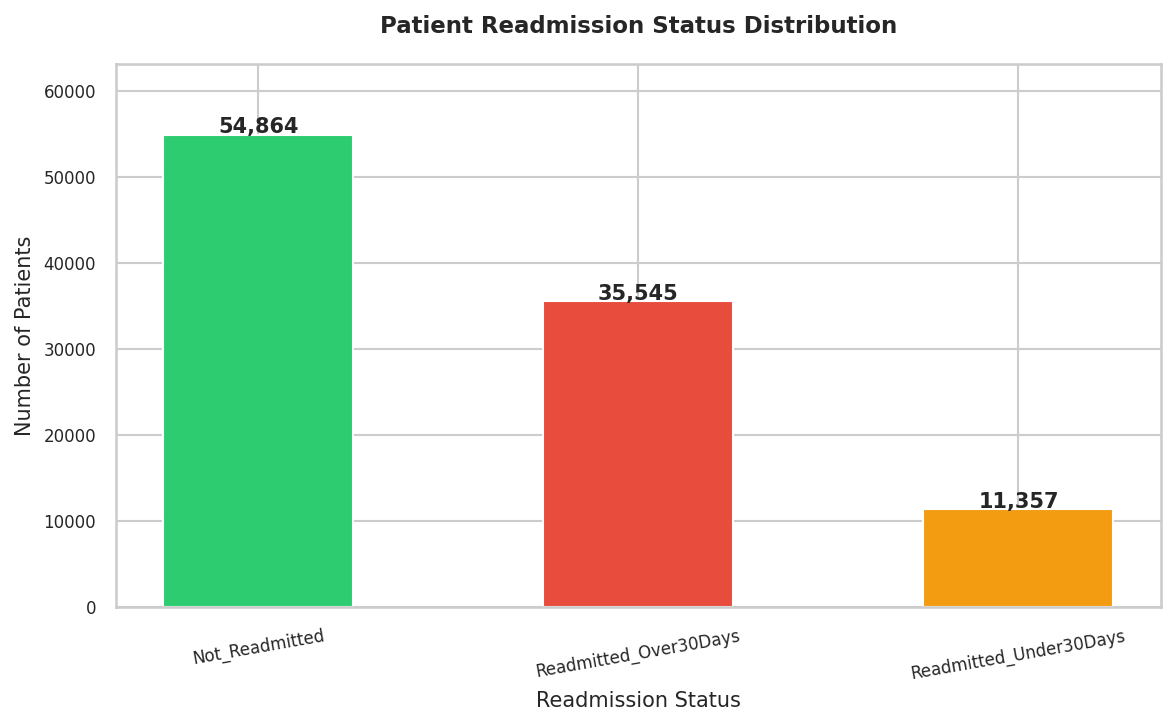

✅ Chart 1 saved!


In [83]:
def plot_readmission(df):
    """
    Bar chart showing count of patients by readmission status.

    Parameters:
        df (pd.DataFrame): Cleaned encounters DataFrame
    Returns:
        None — saves and displays chart
    """
    counts = df['readmission_status'].value_counts()
    colors = ['#2ecc71', '#e74c3c', '#f39c12']

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)

    # Add value labels on top of bars
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 200,
                f'{val:,}', ha='center', fontweight='bold', fontsize=10)

    ax.set_title('Patient Readmission Status Distribution', fontweight='bold', pad=15)
    ax.set_xlabel('Readmission Status')
    ax.set_ylabel('Number of Patients')
    ax.set_ylim(0, counts.max() * 1.15)
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.savefig('/content/health_project/outputs/chart1_readmission.png', bbox_inches='tight')
    plt.show()
    print("✅ Chart 1 saved!")

plot_readmission(encounters_clean)

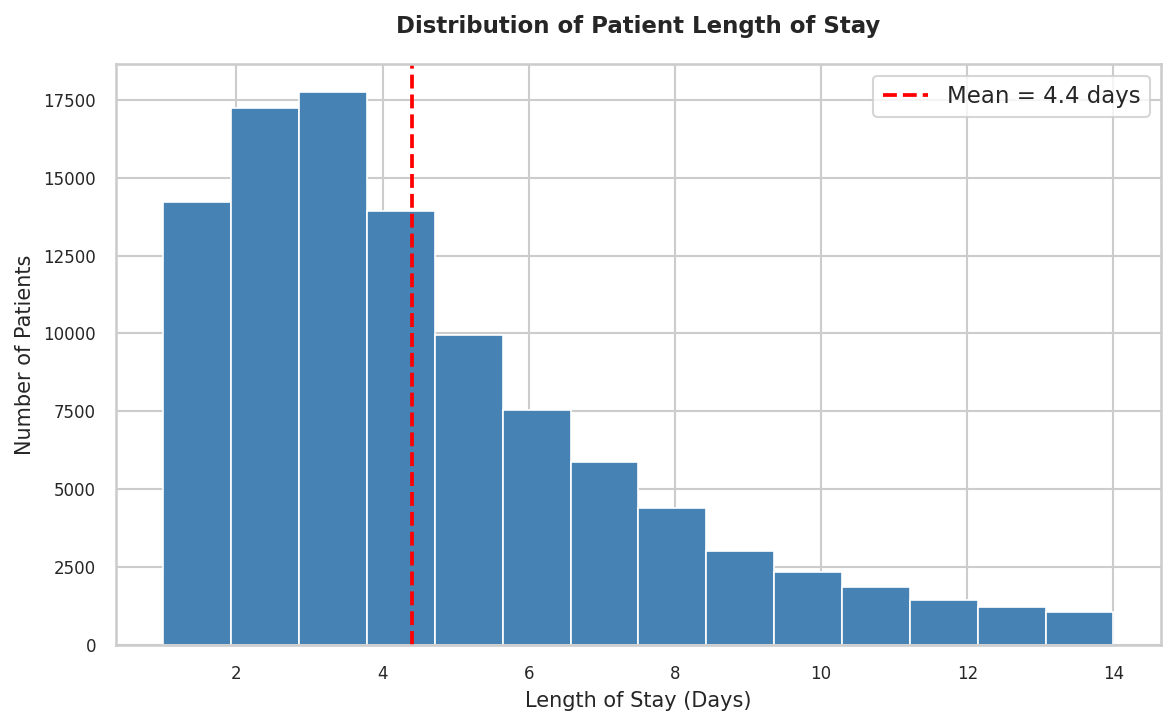

✅ Chart 2 saved!


In [84]:
def plot_length_of_stay(df):
    """
    Histogram showing distribution of patient length of stay in days.

    Parameters:
        df (pd.DataFrame): Cleaned encounters DataFrame
    Returns:
        None — saves and displays chart
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(df['length_of_stay_days'], bins=14,
            color='steelblue', edgecolor='white', linewidth=0.8)

    avg = df['length_of_stay_days'].mean()
    ax.axvline(avg, color='red', linestyle='--', linewidth=1.8, label=f'Mean = {avg:.1f} days')

    ax.set_title('Distribution of Patient Length of Stay', fontweight='bold', pad=15)
    ax.set_xlabel('Length of Stay (Days)')
    ax.set_ylabel('Number of Patients')
    ax.legend()
    plt.tight_layout()
    plt.savefig('/content/health_project/outputs/chart2_length_of_stay.png', bbox_inches='tight')
    plt.show()
    print("✅ Chart 2 saved!")

plot_length_of_stay(encounters_clean)

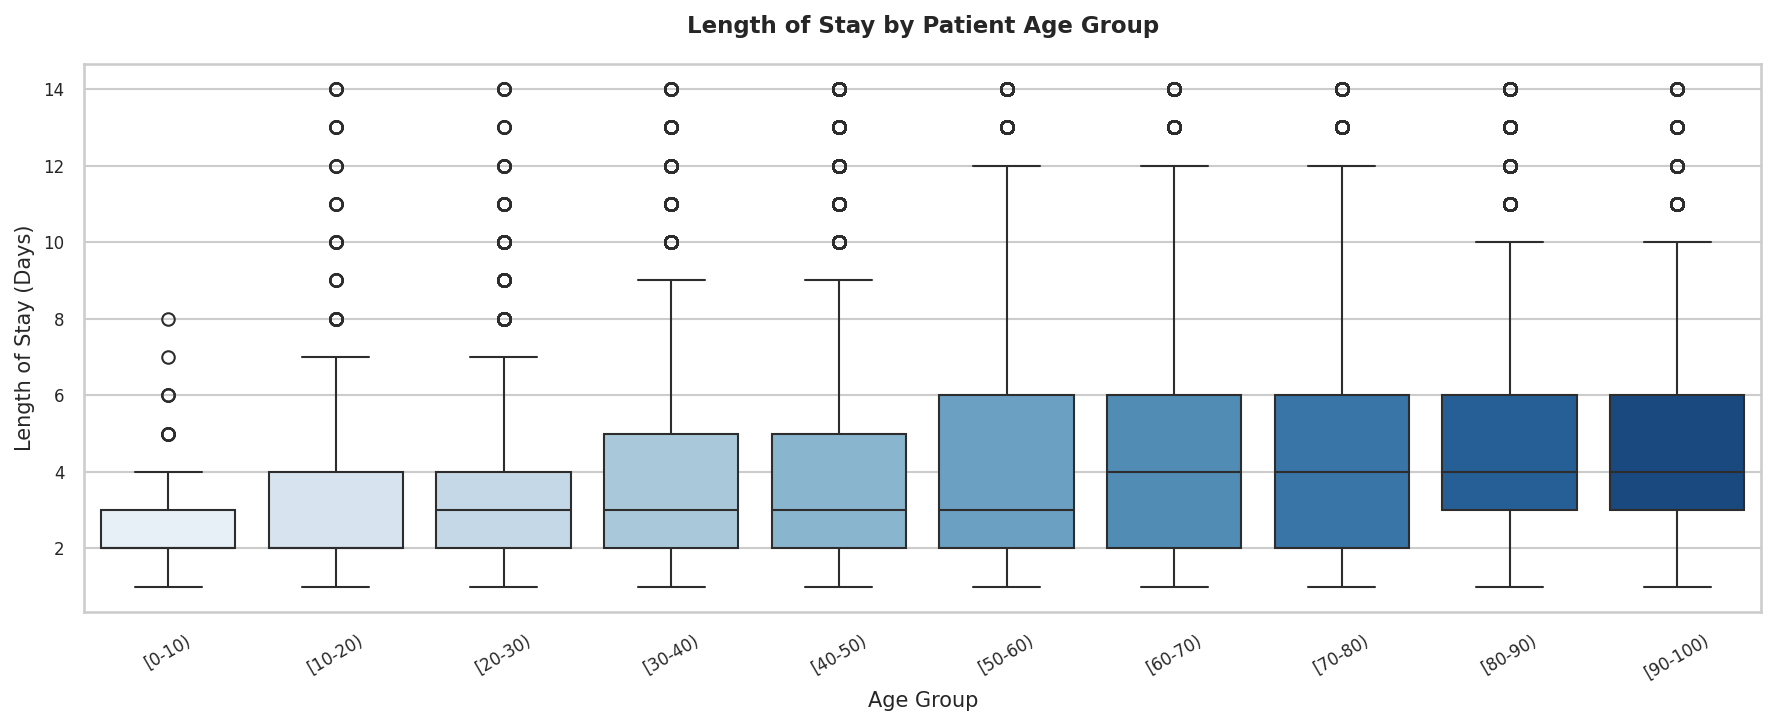

✅ Chart 3 saved!


In [85]:
def plot_age_vs_stay(df):
    """
    Boxplot comparing length of stay across patient age groups.

    Parameters:
        df (pd.DataFrame): Cleaned encounters DataFrame
    Returns:
        None — saves and displays chart
    """
    age_order = [
        '[0-10)','[10-20)','[20-30)','[30-40)','[40-50)',
        '[50-60)','[60-70)','[70-80)','[80-90)','[90-100)'
    ]
    age_order = [a for a in age_order if a in df['age'].values]

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(
        data     = df,
        x        = 'age',
        y        = 'length_of_stay_days',
        order    = age_order,
        palette  = 'Blues',
        ax       = ax
    )

    ax.set_title('Length of Stay by Patient Age Group', fontweight='bold', pad=15)
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Length of Stay (Days)')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig('/content/health_project/outputs/chart3_age_vs_stay.png', bbox_inches='tight')
    plt.show()
    print("✅ Chart 3 saved!")

plot_age_vs_stay(encounters_clean)

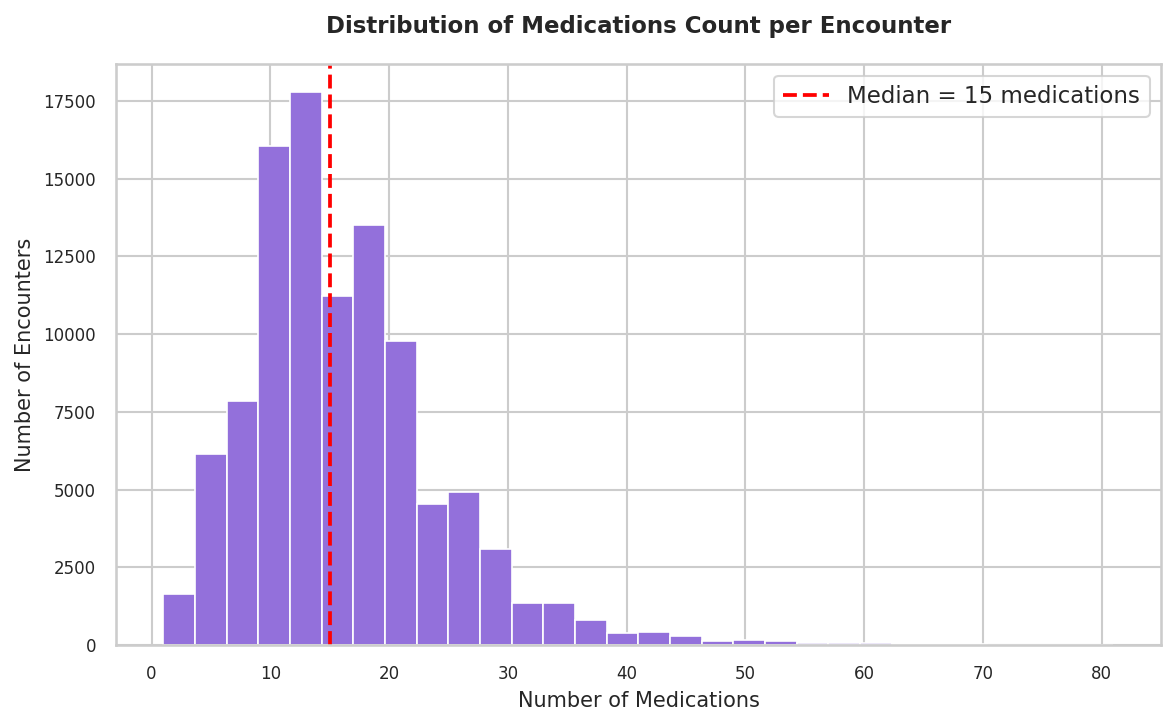

✅ Chart 4 saved!


In [86]:
def plot_medications(df):
    """
    Histogram of number of medications prescribed per encounter.

    Parameters:
        df (pd.DataFrame): Cleaned encounters DataFrame
    Returns:
        None — saves and displays chart
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(df['medications_count'], bins=30,
            color='mediumpurple', edgecolor='white', linewidth=0.8)

    median = df['medications_count'].median()
    ax.axvline(median, color='red', linestyle='--',
               linewidth=1.8, label=f'Median = {median:.0f} medications')

    ax.set_title('Distribution of Medications Count per Encounter', fontweight='bold', pad=15)
    ax.set_xlabel('Number of Medications')
    ax.set_ylabel('Number of Encounters')
    ax.legend()
    plt.tight_layout()
    plt.savefig('/content/health_project/outputs/chart4_medications.png', bbox_inches='tight')
    plt.show()
    print("✅ Chart 4 saved!")

plot_medications(encounters_clean)

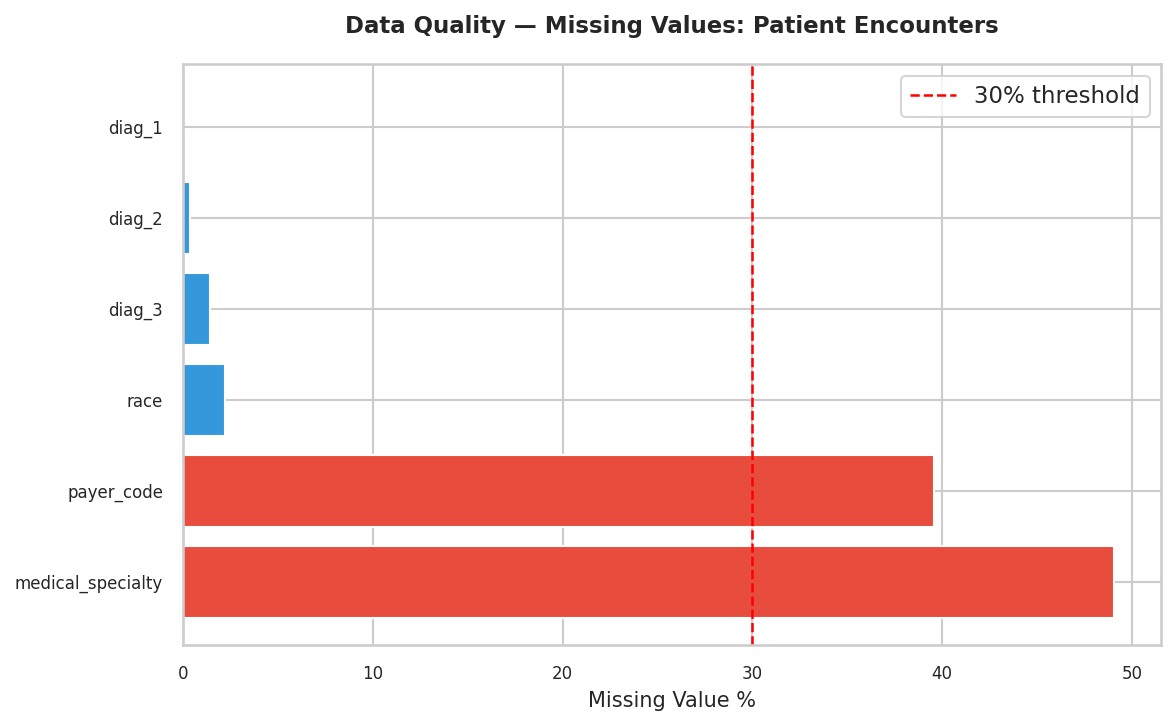

✅ Chart 5 saved!


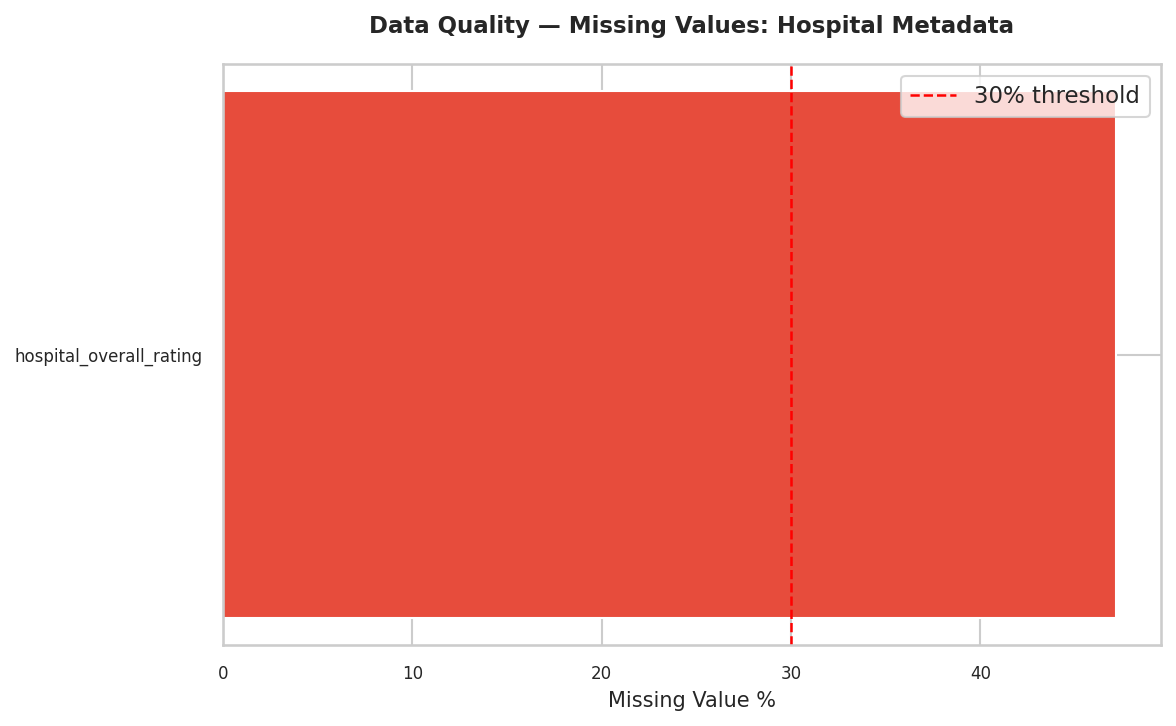

✅ Chart 5 saved!


In [87]:
def plot_missing_values(df, name):
    """
    Horizontal bar chart showing percentage of missing values per column.
    Used for data quality reporting.

    Parameters:
        df   (pd.DataFrame): DataFrame to check
        name (str)         : Label for the chart title
    Returns:
        None — saves and displays chart
    """
    missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]

    fig, ax = plt.subplots(figsize=(8, 5))

    if missing_pct.empty:
        ax.text(0.5, 0.5, '✅ No Missing Values Found!',
                ha='center', va='center', fontsize=14,
                color='green', fontweight='bold')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.axis('off')
    else:
        colors = ['#e74c3c' if v > 30 else '#f39c12' if v > 10 else '#3498db'
                  for v in missing_pct.values]
        ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor='white')
        ax.set_xlabel('Missing Value %')
        ax.axvline(30, color='red', linestyle='--',
                   linewidth=1.2, label='30% threshold')
        ax.legend()

    ax.set_title(f'Data Quality — Missing Values: {name}', fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(f'/content/health_project/outputs/chart5_missing_{name.replace(" ","_")}.png',
                bbox_inches='tight')
    plt.show()
    print("✅ Chart 5 saved!")

plot_missing_values(encounters_clean, "Patient Encounters")
plot_missing_values(hospitals_clean,  "Hospital Metadata")

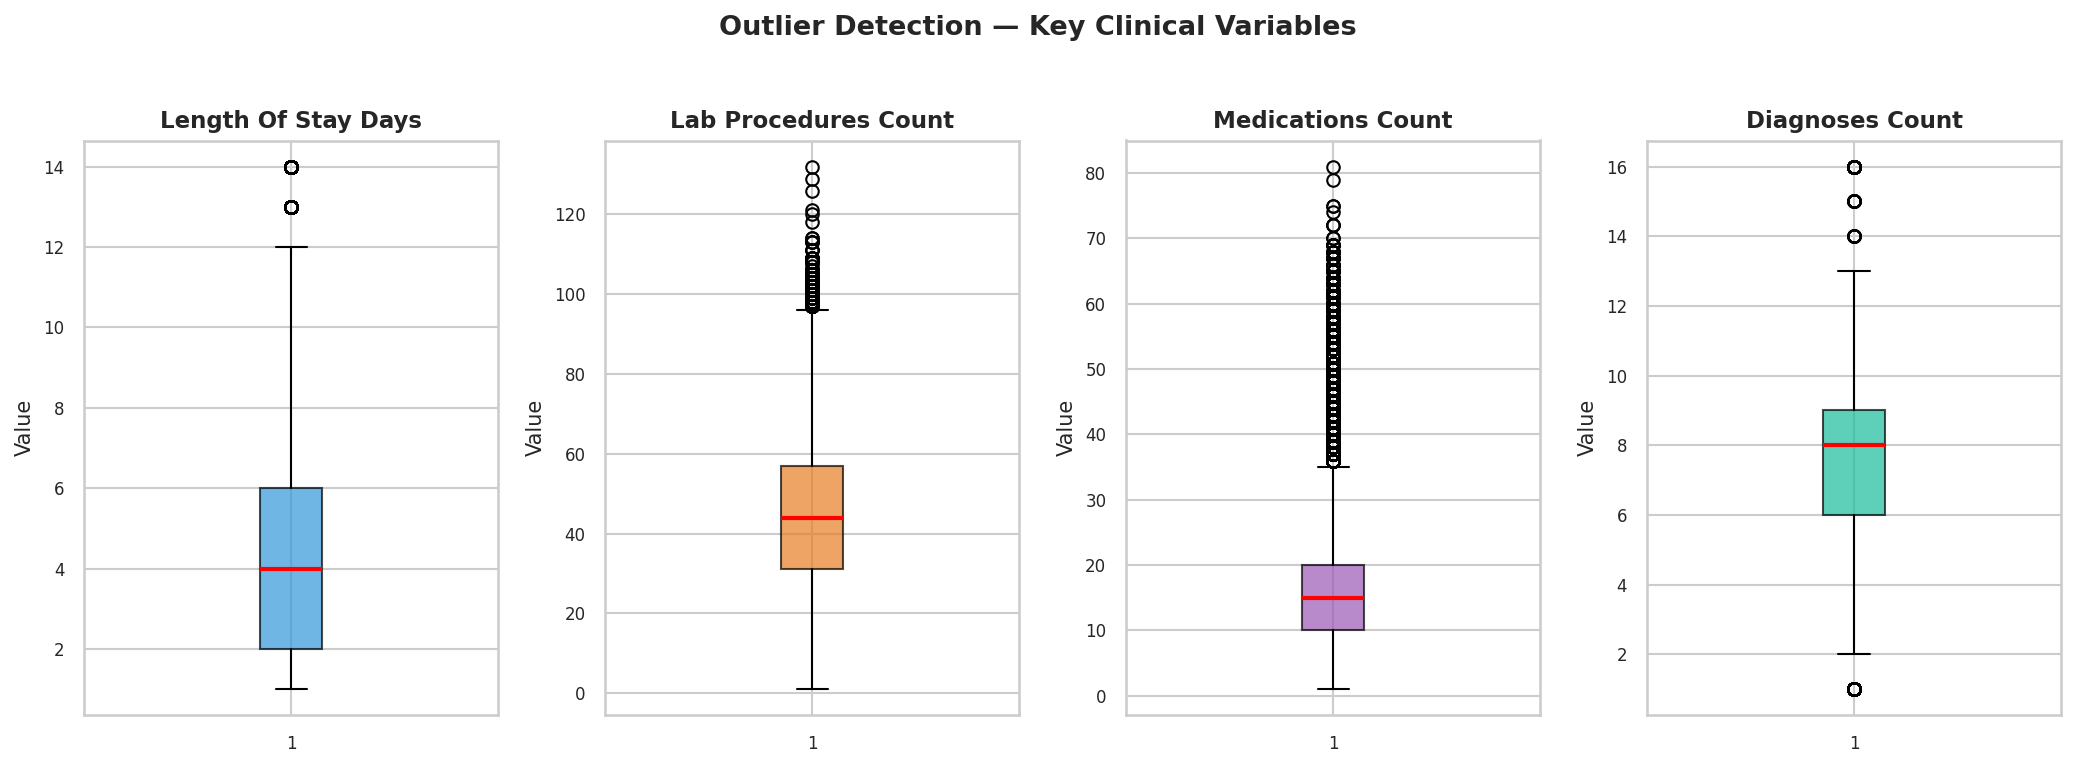

✅ Chart 6 saved!


In [88]:
def plot_outliers(df):
    """
    Side-by-side boxplots for key numeric columns to detect outliers.

    Parameters:
        df (pd.DataFrame): Cleaned encounters DataFrame
    Returns:
        None — saves and displays chart
    """
    cols = ['length_of_stay_days', 'lab_procedures_count',
            'medications_count',   'diagnoses_count']
    cols = [c for c in cols if c in df.columns]

    fig, axes = plt.subplots(1, len(cols), figsize=(14, 5))
    colors = ['#3498db','#e67e22','#9b59b6','#1abc9c']

    for ax, col, color in zip(axes, cols, colors):
        ax.boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
        ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
        ax.set_ylabel('Value')

    fig.suptitle('Outlier Detection — Key Clinical Variables',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('/content/health_project/outputs/chart6_outliers.png', bbox_inches='tight')
    plt.show()
    print("✅ Chart 6 saved!")

plot_outliers(encounters_clean)

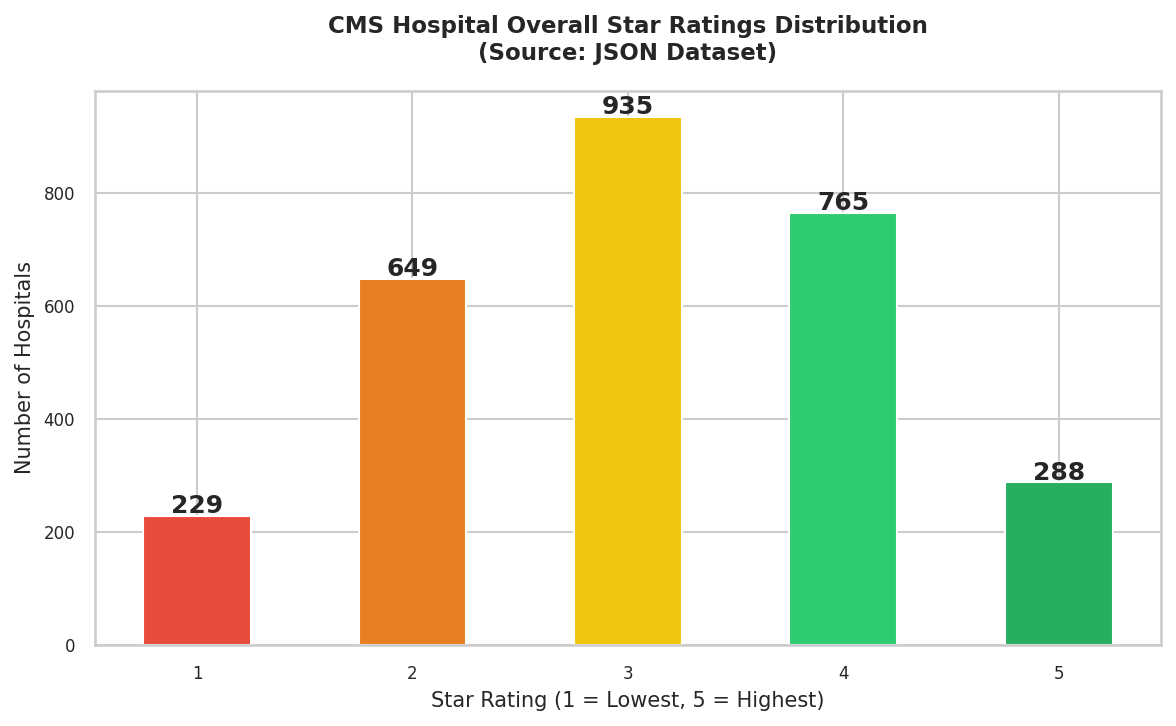

✅ Chart 7 saved!


In [89]:
def plot_hospital_ratings(df):
    """
    Bar chart showing how many hospitals fall in each star rating (1-5).
    Uses the CMS hospital metadata (JSON source).

    Parameters:
        df (pd.DataFrame): Cleaned hospitals DataFrame
    Returns:
        None — saves and displays chart
    """
    if 'hospital_overall_rating' not in df.columns:
        print("⚠️  hospital_overall_rating column not found — skipping")
        return

    rating_counts = df['hospital_overall_rating'].dropna().value_counts().sort_index()
    colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(rating_counts.index.astype(int),
                  rating_counts.values,
                  color=colors[:len(rating_counts)],
                  edgecolor='white', width=0.5)

    for bar, val in zip(bars, rating_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                str(val), ha='center', fontweight='bold')

    ax.set_title('CMS Hospital Overall Star Ratings Distribution\n(Source: JSON Dataset)',
                 fontweight='bold', pad=15)
    ax.set_xlabel('Star Rating (1 = Lowest, 5 = Highest)')
    ax.set_ylabel('Number of Hospitals')
    ax.set_xticks([1, 2, 3, 4, 5])
    plt.tight_layout()
    plt.savefig('/content/health_project/outputs/chart7_hospital_ratings.png', bbox_inches='tight')
    plt.show()
    print("✅ Chart 7 saved!")

plot_hospital_ratings(hospitals_clean)

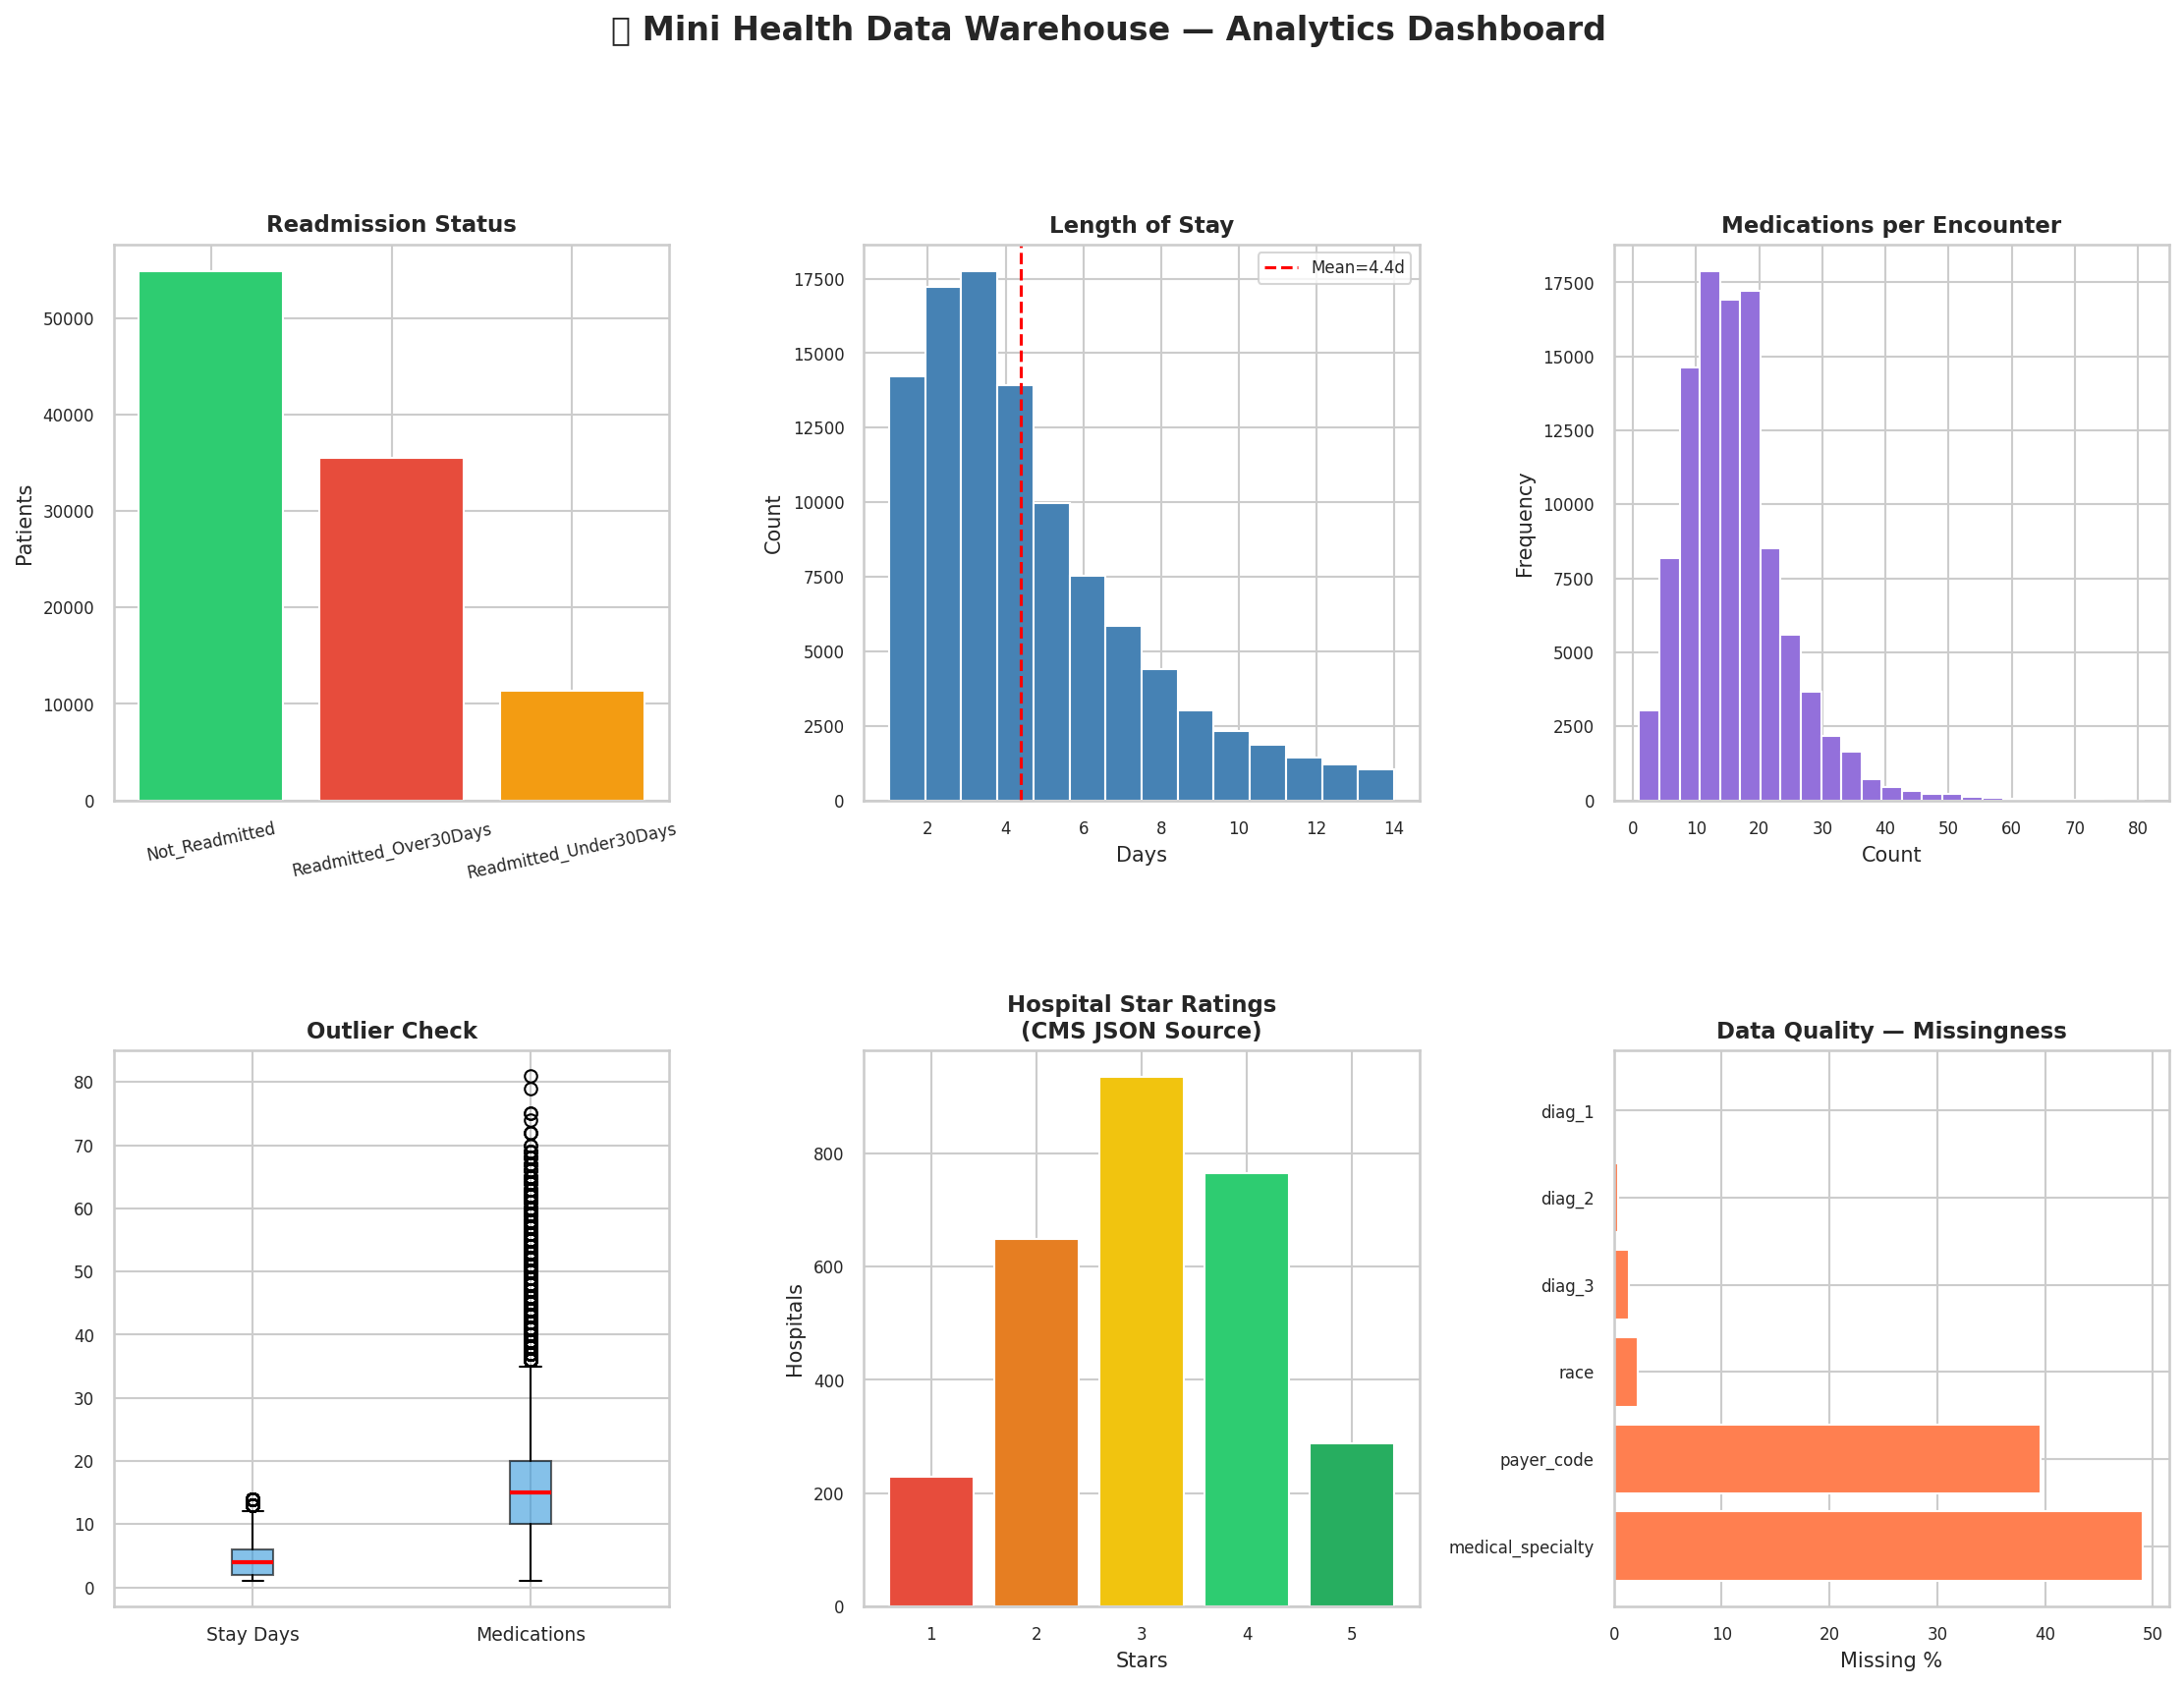

✅ MASTER DASHBOARD saved!


In [90]:
def plot_master_dashboard(encounters_df, hospitals_df):
    """
    Combined dashboard with 6 key charts for executive presentation.
    Covers EDA and data quality visualizations in one figure.

    Parameters:
        encounters_df (pd.DataFrame): Cleaned encounters data
        hospitals_df  (pd.DataFrame): Cleaned hospital metadata
    Returns:
        None — saves and displays dashboard
    """
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('🏥 Mini Health Data Warehouse — Analytics Dashboard',
                 fontsize=16, fontweight='bold', y=1.01)

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # --- Panel 1: Readmission counts ---
    ax1 = fig.add_subplot(gs[0, 0])
    counts  = encounters_df['readmission_status'].value_counts()
    colors1 = ['#2ecc71','#e74c3c','#f39c12']
    ax1.bar(counts.index, counts.values, color=colors1, edgecolor='white')
    ax1.set_title('Readmission Status', fontweight='bold')
    ax1.set_ylabel('Patients')
    ax1.tick_params(axis='x', rotation=12)

    # --- Panel 2: Length of stay histogram ---
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.hist(encounters_df['length_of_stay_days'],
             bins=14, color='steelblue', edgecolor='white')
    ax2.axvline(encounters_df['length_of_stay_days'].mean(),
                color='red', linestyle='--', linewidth=1.5,
                label=f"Mean={encounters_df['length_of_stay_days'].mean():.1f}d")
    ax2.set_title('Length of Stay', fontweight='bold')
    ax2.set_xlabel('Days'); ax2.set_ylabel('Count')
    ax2.legend(fontsize=8)

    # --- Panel 3: Medications histogram ---
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.hist(encounters_df['medications_count'],
             bins=25, color='mediumpurple', edgecolor='white')
    ax3.set_title('Medications per Encounter', fontweight='bold')
    ax3.set_xlabel('Count'); ax3.set_ylabel('Frequency')

    # --- Panel 4: Outlier boxplots ---
    ax4 = fig.add_subplot(gs[1, 0])
    data_box = [
        encounters_df['length_of_stay_days'].dropna(),
        encounters_df['medications_count'].dropna()
    ]
    bp = ax4.boxplot(data_box, patch_artist=True,
                     boxprops=dict(facecolor='#3498db', alpha=0.6),
                     medianprops=dict(color='red', linewidth=2))
    ax4.set_xticks([1, 2])
    ax4.set_xticklabels(['Stay Days', 'Medications'], fontsize=9)
    ax4.set_title('Outlier Check', fontweight='bold')

    # --- Panel 5: Hospital ratings ---
    ax5 = fig.add_subplot(gs[1, 1])
    if 'hospital_overall_rating' in hospitals_df.columns:
        rc = hospitals_df['hospital_overall_rating'].dropna().value_counts().sort_index()
        ax5.bar(rc.index.astype(int), rc.values,
                color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'][:len(rc)],
                edgecolor='white')
        ax5.set_title('Hospital Star Ratings\n(CMS JSON Source)', fontweight='bold')
        ax5.set_xlabel('Stars'); ax5.set_ylabel('Hospitals')
        ax5.set_xticks([1,2,3,4,5])
    else:
        ax5.text(0.5, 0.5, 'Rating data\nnot available',
                 ha='center', va='center', fontsize=12)
        ax5.set_title('Hospital Ratings', fontweight='bold')

    # --- Panel 6: Missing value summary ---
    ax6 = fig.add_subplot(gs[1, 2])
    missing = (encounters_df.isnull().mean() * 100)
    missing = missing[missing > 0].sort_values(ascending=False).head(8)
    if missing.empty:
        ax6.text(0.5, 0.5, '✅ No Missing\nValues!',
                 ha='center', va='center', fontsize=13,
                 color='green', fontweight='bold')
        ax6.axis('off')
    else:
        ax6.barh(missing.index, missing.values, color='coral')
        ax6.set_xlabel('Missing %')
    ax6.set_title('Data Quality — Missingness', fontweight='bold')

    plt.savefig('/content/health_project/outputs/MASTER_DASHBOARD.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ MASTER DASHBOARD saved!")

plot_master_dashboard(encounters_clean, hospitals_clean)

In [91]:
import os

output_files = os.listdir('/content/health_project/outputs/')
charts = [f for f in output_files if f.endswith('.png')]

print("=" * 55)
print("   ✅ STEP 8 — ALL CHARTS SAVED")
print("=" * 55)
for c in sorted(charts):
    print(f"  🖼️  {c}")
print(f"\n  Total charts created : {len(charts)}")
print("=" * 55)
logging.info(f"Step 8 complete — {len(charts)} charts saved")

   ✅ STEP 8 — ALL CHARTS SAVED
  🖼️  MASTER_DASHBOARD.png
  🖼️  chart1_readmission.png
  🖼️  chart2_length_of_stay.png
  🖼️  chart3_age_vs_stay.png
  🖼️  chart4_medications.png
  🖼️  chart5_missing_Hospital_Metadata.png
  🖼️  chart5_missing_Patient_Encounters.png
  🖼️  chart6_outliers.png
  🖼️  chart7_hospital_ratings.png
  🖼️  pipeline_DAG.png

  Total charts created : 10


In [92]:
# ============================================================
# STEP 9: DATA GOVERNANCE & LINEAGE TRACKING
# ============================================================

import datetime
import json

def create_lineage_log(encounters_raw, encounters_clean,
                        hospitals_raw,  hospitals_clean):
    """
    Create a full data lineage log documenting where data came from,
    how it was transformed, who is responsible, and what was produced.
    Saves log as JSON for auditability.

    Parameters:
        encounters_raw   (pd.DataFrame): Original encounters data
        encounters_clean (pd.DataFrame): Cleaned encounters data
        hospitals_raw    (pd.DataFrame): Original hospitals data
        hospitals_clean  (pd.DataFrame): Cleaned hospitals data
    Returns:
        dict: Full lineage log dictionary
    """
    log = {
        "pipeline_name"     : "Mini Health Data Warehouse",
        "version"           : "v1.0",
        "run_timestamp"     : str(datetime.datetime.now()),
        "run_by"            : "Health Informatics Pipeline",
        "schema_version"    : "v1.0",

        # --- Governance Roles ---
        "governance": {
            "data_owner"    : "Hospital Administration / CMS",
            "data_steward"  : "Health Informatics Team",
            "pipeline_engineer": "Data Engineering Student",
            "data_consumers": ["Clinical Analysts", "Hospital Management",
                               "Quality Improvement Teams"]
        },

        # --- Source Datasets ---
        "data_sources": [
            {
                "name"           : "Diabetes 130-US Hospitals Dataset",
                "format"         : "CSV",
                "source"         : "UCI Machine Learning Repository",
                "url"            : "https://archive.ics.uci.edu/dataset/296",
                "license"        : "Open Access — Creative Commons",
                "rows_raw"       : len(encounters_raw),
                "columns_raw"    : len(encounters_raw.columns),
                "rows_clean"     : len(encounters_clean),
                "columns_clean"  : len(encounters_clean.columns),
                "rows_removed"   : len(encounters_raw) - len(encounters_clean)
            },
            {
                "name"           : "CMS Hospital General Information",
                "format"         : "JSON",
                "source"         : "Centers for Medicare & Medicaid Services",
                "url"            : "https://data.cms.gov/provider-data/dataset/xubh-q36u",
                "license"        : "Open Government Data — Public Domain",
                "rows_raw"       : len(hospitals_raw),
                "columns_raw"    : len(hospitals_raw.columns),
                "rows_clean"     : len(hospitals_clean),
                "columns_clean"  : len(hospitals_clean.columns),
                "rows_removed"   : len(hospitals_raw) - len(hospitals_clean)
            }
        ],

        # --- Transformations Applied ---
        "transformations": [
            {
                "step"       : 1,
                "name"       : "Duplicate Removal",
                "description": "Removed exact duplicate rows from both datasets",
                "method"     : "df.drop_duplicates()"
            },
            {
                "step"       : 2,
                "name"       : "Column Renaming",
                "description": "Renamed columns to readable snake_case format",
                "method"     : "df.rename(columns=rename_map)"
            },
            {
                "step"       : 3,
                "name"       : "Age Range Conversion",
                "description": "Converted age bracket strings to numeric midpoints",
                "method"     : "df['age'].map(age_map)"
            },
            {
                "step"       : 4,
                "name"       : "Readmission Label Standardization",
                "description": "Replaced <30, >30, NO with descriptive labels",
                "method"     : "df['readmission_status'].replace()"
            },
            {
                "step"       : 5,
                "name"       : "High-Missingness Column Removal",
                "description": "Dropped columns with over 50% missing values",
                "method"     : "df.drop(columns=cols_to_drop)"
            },
            {
                "step"       : 6,
                "name"       : "Null Imputation",
                "description": "Filled remaining numeric nulls with column median",
                "method"     : "df.fillna(df.median())"
            },
            {
                "step"       : 7,
                "name"       : "Medication Melt",
                "description": "Reshaped medication columns from wide to long format",
                "method"     : "df.melt(id_vars=['encounter_id','patient_id'])"
            },
            {
                "step"       : 8,
                "name"       : "Hospital Aggregation",
                "description": "Computed encounter counts, avg stay, readmission rate per hospital",
                "method"     : "df.groupby('hospital_id').agg()"
            },
            {
                "step"       : 9,
                "name"       : "Dataset Merge",
                "description": "Joined encounter summary with CMS hospital metadata",
                "method"     : "pd.merge(hospital_summary, hospitals_copy, on='hospital_id')"
            }
        ],

        # --- Output Tables ---
        "output_tables": [
            {"table": "patient_encounters", "rows": len(encounters_clean),  "format": "SQLite"},
            {"table": "hospital_metadata",  "rows": len(hospitals_clean),   "format": "SQLite"},
            {"table": "hospital_summary",   "rows": len(hospital_summary),  "format": "SQLite"},
            {"table": "medications_long",   "rows": len(medications_long),  "format": "SQLite"}
        ],

        # --- Versioning Strategy ---
        "versioning": {
            "strategy"        : "Date-stamped file versions + schema version tag",
            "current_version" : "v1.0",
            "next_version"    : "v1.1 — when new data source added or schema changes",
            "change_log"      : "Tracked in this lineage log JSON file",
            "backup_policy"   : "Daily snapshot to Google Drive / cloud storage"
        },

        # --- Scheduling ---
        "scheduling": {
            "frequency"    : "Daily at 02:00 AM UTC",
            "trigger"      : "Time-based or on new file arrival",
            "tool"         : "Apache Airflow (recommended for production)",
            "current_mode" : "Manual execution via Jupyter/Colab notebook"
        }
    }

    # Save to file
    log_path = '/content/health_project/outputs/lineage_log.json'
    with open(log_path, 'w') as f:
        json.dump(log, f, indent=4)

    logging.info("Lineage log created and saved")
    print(f"✅ Lineage log saved → {log_path}")
    return log

lineage_log = create_lineage_log(
    encounters_df,   encounters_clean,
    hospitals_df,    hospitals_clean
)

✅ Lineage log saved → /content/health_project/outputs/lineage_log.json


In [93]:
print("\n")
print("=" * 60)
print("   📋 DATA GOVERNANCE SUMMARY")
print("=" * 60)

print(f"""
  PIPELINE
  ─────────────────────────────────────────────
  Name            : {lineage_log['pipeline_name']}
  Version         : {lineage_log['version']}
  Run Timestamp   : {lineage_log['run_timestamp']}
  Schema Version  : {lineage_log['schema_version']}

  ROLES & RESPONSIBILITIES
  ─────────────────────────────────────────────
  Data Owner      : {lineage_log['governance']['data_owner']}
  Data Steward    : {lineage_log['governance']['data_steward']}
  Pipeline Eng.   : {lineage_log['governance']['pipeline_engineer']}

  DATA SOURCES
  ─────────────────────────────────────────────""")

for src in lineage_log['data_sources']:
    print(f"""
  [{src['format']}] {src['name']}
      Source      : {src['source']}
      Rows (raw)  : {src['rows_raw']:,}
      Rows (clean): {src['rows_clean']:,}
      Rows removed: {src['rows_removed']:,}""")

print(f"""
  TRANSFORMATIONS APPLIED
  ─────────────────────────────────────────────""")
for t in lineage_log['transformations']:
    print(f"  Step {t['step']}: {t['name']}")

print(f"""
  OUTPUT TABLES (SQLite)
  ─────────────────────────────────────────────""")
for t in lineage_log['output_tables']:
    print(f"  📋 {t['table']:30s} → {t['rows']:,} rows")

print(f"""
  SCHEDULING
  ─────────────────────────────────────────────
  Frequency       : {lineage_log['scheduling']['frequency']}
  Production Tool : {lineage_log['scheduling']['tool']}
""")
print("=" * 60)



   📋 DATA GOVERNANCE SUMMARY

  PIPELINE
  ─────────────────────────────────────────────
  Name            : Mini Health Data Warehouse
  Version         : v1.0
  Run Timestamp   : 2026-04-27 23:17:34.979124
  Schema Version  : v1.0

  ROLES & RESPONSIBILITIES
  ─────────────────────────────────────────────
  Data Owner      : Hospital Administration / CMS
  Data Steward    : Health Informatics Team
  Pipeline Eng.   : Data Engineering Student

  DATA SOURCES
  ─────────────────────────────────────────────

  [CSV] Diabetes 130-US Hospitals Dataset
      Source      : UCI Machine Learning Repository
      Rows (raw)  : 101,766
      Rows (clean): 101,766
      Rows removed: 0

  [JSON] CMS Hospital General Information
      Source      : Centers for Medicare & Medicaid Services
      Rows (raw)  : 5,426
      Rows (clean): 5,426
      Rows removed: 0

  TRANSFORMATIONS APPLIED
  ─────────────────────────────────────────────
  Step 1: Duplicate Removal
  Step 2: Column Renaming
  Step

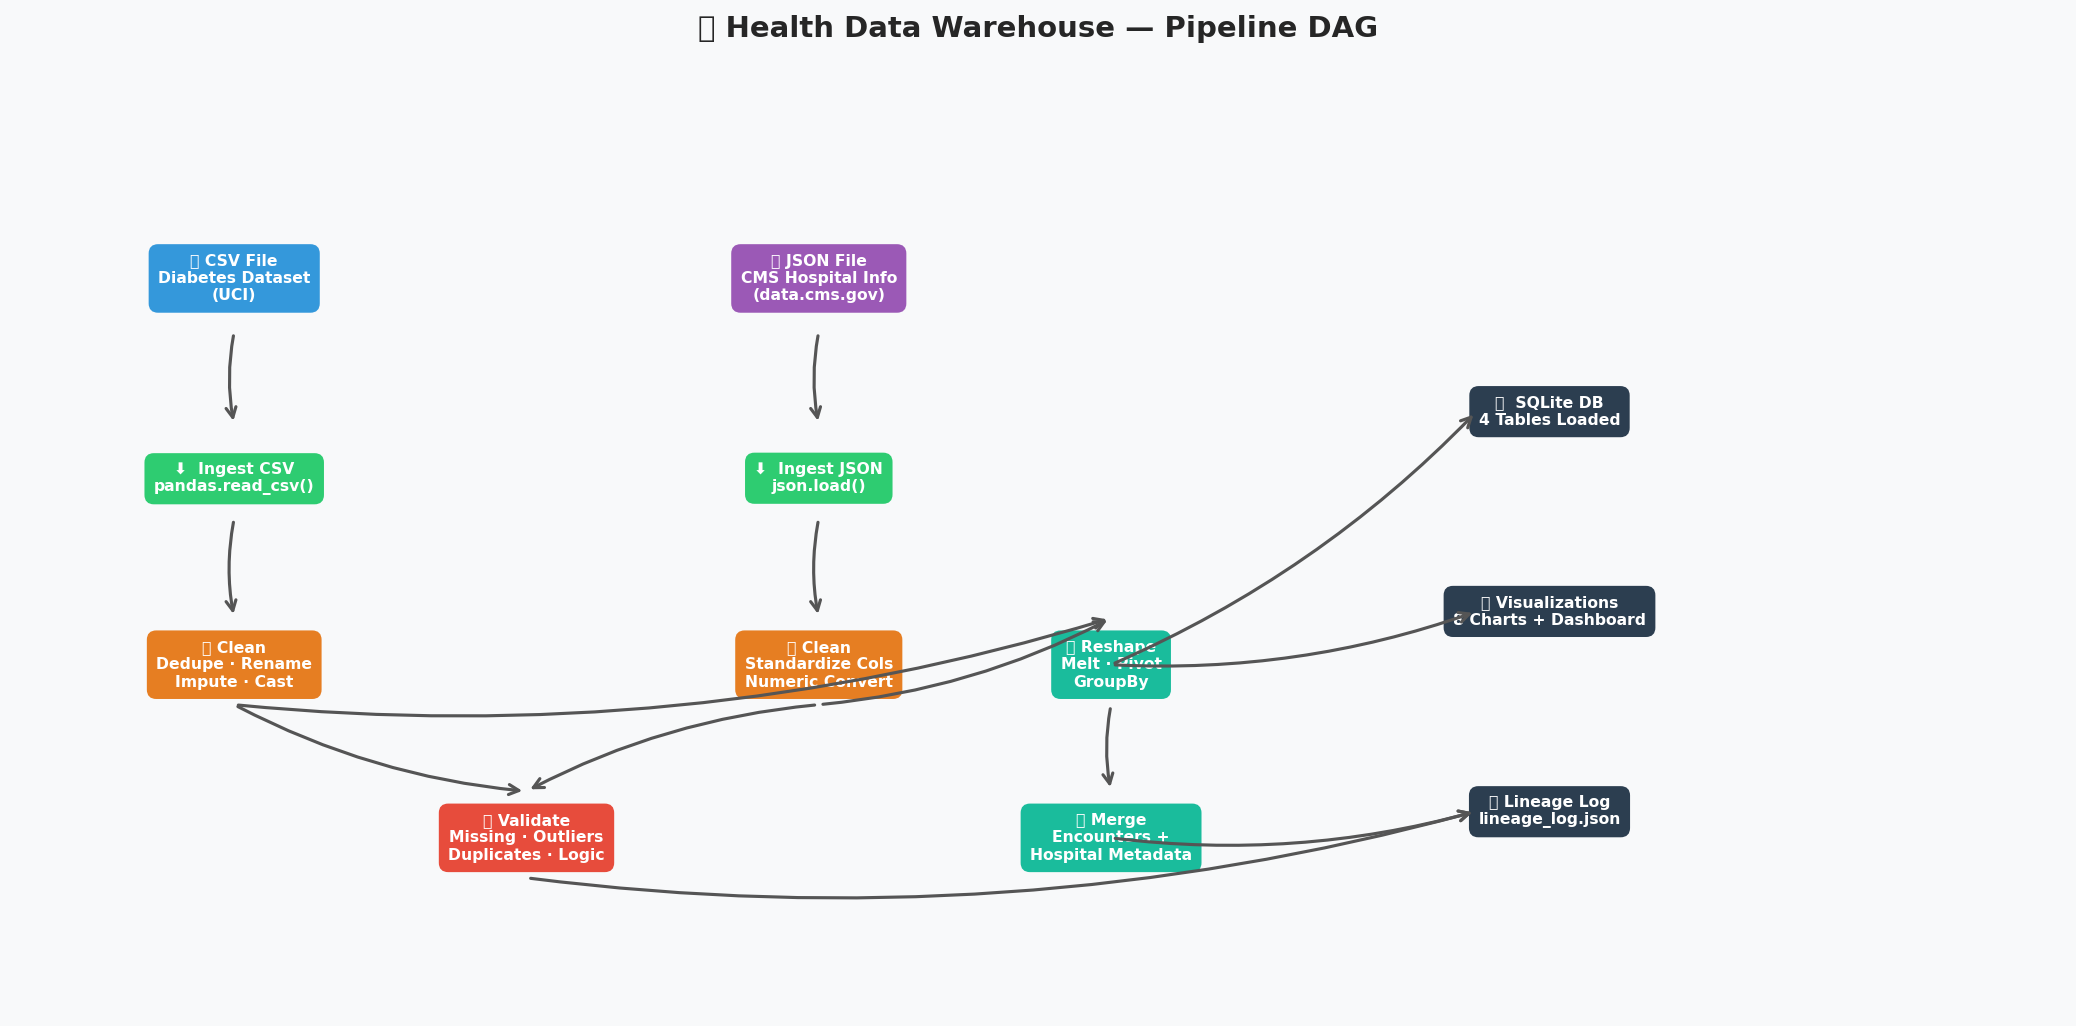

✅ Pipeline DAG saved!


In [94]:
def plot_pipeline_dag():
    """
    Create a visual DAG (Directed Acyclic Graph) showing
    the end-to-end data pipeline flow from source to output.

    Returns:
        None — saves and displays diagram
    """
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 7)
    ax.axis('off')
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('#f8f9fa')

    # Box style
    box_style = dict(boxstyle='round,pad=0.5', linewidth=1.5)

    # --- Define boxes: (x, y, label, color) ---
    boxes = [
        # Row 1 — Sources
        (1.5, 5.5, "📄 CSV File\nDiabetes Dataset\n(UCI)", '#3498db'),
        (5.5, 5.5, "📋 JSON File\nCMS Hospital Info\n(data.cms.gov)", '#9b59b6'),

        # Row 2 — Ingestion
        (1.5, 4.0, "⬇️  Ingest CSV\npandas.read_csv()", '#2ecc71'),
        (5.5, 4.0, "⬇️  Ingest JSON\njson.load()", '#2ecc71'),

        # Row 3 — Cleaning
        (1.5, 2.6, "🧹 Clean\nDedupe · Rename\nImpute · Cast", '#e67e22'),
        (5.5, 2.6, "🧹 Clean\nStandardize Cols\nNumeric Convert", '#e67e22'),

        # Row 4 — Validate
        (3.5, 1.3, "✅ Validate\nMissing · Outliers\nDuplicates · Logic", '#e74c3c'),

        # Row 5 — Reshape & Merge
        (7.5, 2.6, "🔀 Reshape\nMelt · Pivot\nGroupBy", '#1abc9c'),
        (7.5, 1.3, "🔗 Merge\nEncounters +\nHospital Metadata", '#1abc9c'),

        # Row 6 — Outputs
        (10.5, 4.5, "🗄️  SQLite DB\n4 Tables Loaded", '#2c3e50'),
        (10.5, 3.0, "📊 Visualizations\n8 Charts + Dashboard", '#2c3e50'),
        (10.5, 1.5, "📋 Lineage Log\nlineage_log.json", '#2c3e50'),
    ]

    # Draw boxes
    for (x, y, label, color) in boxes:
        ax.text(x, y, label, ha='center', va='center',
                fontsize=7.5, fontweight='bold', color='white',
                bbox=dict(**box_style, facecolor=color, edgecolor=color))

    # Draw arrows
    arrows = [
        (1.5,5.1,  1.5,4.4),   # CSV → Ingest CSV
        (5.5,5.1,  5.5,4.4),   # JSON → Ingest JSON
        (1.5,3.7,  1.5,2.95),  # Ingest → Clean encounters
        (5.5,3.7,  5.5,2.95),  # Ingest → Clean hospitals
        (1.5,2.3,  3.5,1.65),  # Clean enc → Validate
        (5.5,2.3,  3.5,1.65),  # Clean hosp → Validate
        (5.5,2.3,  7.5,2.95),  # Clean hosp → Reshape
        (1.5,2.3,  7.5,2.95),  # Clean enc → Reshape
        (7.5,2.3,  7.5,1.65),  # Reshape → Merge
        (7.5,2.6,  10.0,4.5),  # → SQL
        (7.5,2.6,  10.0,3.0),  # → Charts
        (3.5,1.0,  10.0,1.5),  # Validate → Lineage Log
        (7.5,1.3,  10.0,1.5),  # Merge → Lineage Log
    ]

    for (x1,y1,x2,y2) in arrows:
        ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle='->', color='#555',
                                   lw=1.5, connectionstyle='arc3,rad=0.1'))

    ax.set_title('🏥 Health Data Warehouse — Pipeline DAG',
                 fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig('/content/health_project/outputs/pipeline_DAG.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Pipeline DAG saved!")

plot_pipeline_dag()

In [95]:
import os

all_files = os.listdir('/content/health_project/outputs/')

print("\n")
print("=" * 55)
print("   ✅ STEP 9 COMPLETE — ALL OUTPUT FILES")
print("=" * 55)

icons = {
    '.png' : '🖼️ ',
    '.db'  : '🗄️ ',
    '.json': '📋',
    '.log' : '📝'
}

for f in sorted(all_files):
    ext  = os.path.splitext(f)[1]
    icon = icons.get(ext, '📄')
    size = os.path.getsize(f'/content/health_project/outputs/{f}')
    print(f"  {icon}  {f:45s} {size/1024:6.1f} KB")

print("=" * 55)
logging.info("Step 9 complete — governance and lineage documented")



   ✅ STEP 9 COMPLETE — ALL OUTPUT FILES
  🖼️   MASTER_DASHBOARD.png                           168.4 KB
  🖼️   chart1_readmission.png                          53.0 KB
  🖼️   chart2_length_of_stay.png                       42.0 KB
  🖼️   chart3_age_vs_stay.png                          56.8 KB
  🖼️   chart4_medications.png                          45.9 KB
  🖼️   chart5_missing_Hospital_Metadata.png            32.4 KB
  🖼️   chart5_missing_Patient_Encounters.png           40.2 KB
  🖼️   chart6_outliers.png                             68.6 KB
  🖼️   chart7_hospital_ratings.png                     46.8 KB
  🗄️   health_warehouse.db                           57092.0 KB
  📋  lineage_log.json                                 4.6 KB
  🖼️   pipeline_DAG.png                               125.2 KB


In [96]:
import shutil

# Zip the entire outputs folder
shutil.make_archive(
    '/content/health_project_FINAL',
    'zip',
    '/content/health_project'
)
print("✅ ZIP file created!")

# Download it
from google.colab import files
files.download('/content/health_project_FINAL.zip')
print("✅ Downloading to your computer...")

✅ ZIP file created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloading to your computer...
